In [ ]:
# =============================================================================
# CELL 1: LIBRARIES, PROJECT SETTINGS AND EVALUATION FUNCTIONS
# =============================================================================

import os
import time
import warnings
import itertools
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from IPython.display import display
from dateutil.easter import easter
from scipy import stats

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# Forecasting settings
TEST_WEEKS = 104
SEASONAL_PERIOD = 52

HEATING_BASE = 15.5
COOLING_BASE = 22.0


# Official data source
LOAD_SOURCE = (
    "https://data.open-power-system-data.org/time_series/"
    "2020-10-06/time_series_60min_singleindex.csv"
)


# Project folders
OUTPUT_DIR = Path("calendar_outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DATA_DIR = Path("calendar_data")

for folder in [
    OUTPUT_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    DATA_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


def calculate_rmse(y_true, y_pred):
    """Calculate root mean squared error."""

    return float(
        np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )
    )


def calculate_smape(y_true, y_pred):
    """Calculate symmetric mean absolute percentage error."""

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    denominator = (
        np.abs(y_true)
        + np.abs(y_pred)
    )

    valid = denominator != 0

    return float(
        200
        * np.mean(
            np.abs(
                y_pred[valid]
                - y_true[valid]
            )
            / denominator[valid]
        )
    )


def calculate_mase(
    y_true,
    y_pred,
    y_train,
    seasonality=52
):
    """Calculate mean absolute scaled error."""

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    y_train = np.asarray(
        y_train,
        dtype=float
    )

    seasonal_scale = np.mean(
        np.abs(
            y_train[seasonality:]
            - y_train[:-seasonality]
        )
    )

    return float(
        np.mean(
            np.abs(
                y_true - y_pred
            )
        )
        / seasonal_scale
    )


def evaluate_forecast(
    model_name,
    y_true,
    y_pred,
    y_train,
    forecast_status
):
    """Calculate the main forecasting metrics."""

    y_true = pd.Series(
        y_true
    ).astype(float)

    y_pred = pd.Series(
        y_pred,
        index=y_true.index
    ).astype(float)

    return {
        "Model": model_name,
        "Status": forecast_status,

        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),

        "RMSE": calculate_rmse(
            y_true,
            y_pred
        ),

        "MASE": calculate_mase(
            y_true,
            y_pred,
            y_train,
            SEASONAL_PERIOD
        ),

        "sMAPE": calculate_smape(
            y_true,
            y_pred
        ),

        "Bias": float(
            np.mean(
                y_pred - y_true
            )
        )
    }


def run_stationarity_tests(
    series,
    series_name
):
    """Apply ADF and KPSS stationarity tests."""

    series = pd.Series(
        series
    ).dropna()

    adf_result = adfuller(
        series,
        autolag="AIC"
    )

    try:
        kpss_result = kpss(
            series,
            regression="c",
            nlags="auto"
        )

        kpss_statistic = kpss_result[0]
        kpss_p_value = kpss_result[1]

    except Exception:
        kpss_statistic = np.nan
        kpss_p_value = np.nan

    return {
        "Series": series_name,
        "Observations": len(series),
        "ADF statistic": adf_result[0],
        "ADF p-value": adf_result[1],
        "KPSS statistic": kpss_statistic,
        "KPSS p-value": kpss_p_value
    }


def save_figure(filename):
    """Save and display the current figure."""

    plt.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


def shade_holiday_weeks(
    axis,
    calendar_frame,
    alpha=0.08
):
    """Shade holiday weeks on a forecasting plot."""

    holiday_dates = calendar_frame.index[
        calendar_frame[
            "is_holiday_week"
        ] == 1
    ]

    for date in holiday_dates:

        axis.axvspan(
            date - pd.Timedelta(days=3),
            date + pd.Timedelta(days=3),
            alpha=alpha
        )


print("Environment prepared successfully.")
print(f"Electricity data source: {LOAD_SOURCE}")
print(f"Output folder: {OUTPUT_DIR.resolve()}")

Environment prepared successfully.
Electricity data source: https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv
Output folder: /content/calendar_outputs


In [ ]:
# =============================================================================
# CELL 2: LOAD ELECTRICITY DEMAND AND WEATHER DATA
# =============================================================================

load_data = pd.read_csv(
    LOAD_SOURCE,
    usecols=[
        "utc_timestamp",
        "DE_load_actual_entsoe_transparency"
    ],
    parse_dates=[
        "utc_timestamp"
    ]
)

load_data = load_data.rename(
    columns={
        "utc_timestamp": "date",
        "DE_load_actual_entsoe_transparency": "load_mw"
    }
)

load_data["date"] = (
    pd.to_datetime(
        load_data["date"],
        utc=True
    )
    .dt.tz_convert(None)
)

load_data = load_data.sort_values(
    "date"
)

duplicate_count = int(
    load_data["date"]
    .duplicated()
    .sum()
)

load_data = (
    load_data
    .drop_duplicates(
        subset="date"
    )
    .set_index("date")
)

load_data = load_data.loc[
    "2015-01-01":
]

load_data["load_mw"] = pd.to_numeric(
    load_data["load_mw"],
    errors="coerce"
)


# Hourly load in gigawatts
hourly_load_gw = (
    load_data["load_mw"]
    .asfreq("h")
    / 1000
)

hourly_load_gw.name = "load_gw"


# Daily average load
daily_load_gw = (
    hourly_load_gw
    .resample("D")
    .mean()
)

daily_load_gw.name = "load_gw"


# Weekly average load
weekly_hour_count = (
    hourly_load_gw
    .resample("W-SUN")
    .count()
)

weekly_load_gw = (
    hourly_load_gw
    .resample("W-SUN")
    .mean()
)

complete_week_dates = weekly_hour_count[
    weekly_hour_count == 168
].index

weekly_load_gw = weekly_load_gw.loc[
    complete_week_dates
]

weekly_load_gw.name = "load_gw"


# Berlin daily temperature
temperature_cache = (
    DATA_DIR
    / "berlin_temperature_daily.csv"
)

if temperature_cache.exists():

    temperature_daily = pd.read_csv(
        temperature_cache,
        parse_dates=["date"]
    ).set_index("date")

else:

    temperature_url = (
        "https://archive-api.open-meteo.com/"
        "v1/archive"
    )

    temperature_parameters = {
        "latitude": 52.52,
        "longitude": 13.41,

        "start_date": str(
            hourly_load_gw.index
            .min()
            .date()
        ),

        "end_date": str(
            hourly_load_gw.index
            .max()
            .date()
        ),

        "daily": "temperature_2m_mean",
        "timezone": "Europe/Berlin"
    }

    response = requests.get(
        temperature_url,
        params=temperature_parameters,
        timeout=120
    )

    response.raise_for_status()

    temperature_json = (
        response.json()["daily"]
    )

    temperature_daily = pd.DataFrame(
        {
            "date": pd.to_datetime(
                temperature_json["time"]
            ),

            "temperature_2m_mean": (
                pd.to_numeric(
                    temperature_json[
                        "temperature_2m_mean"
                    ]
                )
            )
        }
    ).set_index("date")

    temperature_daily.reset_index().to_csv(
        temperature_cache,
        index=False
    )


quality_summary = pd.DataFrame(
    {
        "Quality check": [
            "Hourly observations",
            "Missing hourly values",
            "Duplicate timestamps removed",
            "Complete weekly observations",
            "Weekly start date",
            "Weekly end date"
        ],

        "Result": [
            len(hourly_load_gw),

            int(
                hourly_load_gw
                .isna()
                .sum()
            ),

            duplicate_count,

            len(weekly_load_gw),

            weekly_load_gw
            .index
            .min()
            .date(),

            weekly_load_gw
            .index
            .max()
            .date()
        ]
    }
)

display(
    quality_summary
)

,Quality check,Result
0,Hourly observations,50400
1,Missing hourly values,0
2,Duplicate timestamps removed,0
3,Complete weekly observations,299
4,Weekly start date,2015-01-11
5,Weekly end date,2020-09-27


In [ ]:
# =============================================================================
# CELL 3: CREATE DAILY AND WEEKLY CALENDAR FEATURES
# =============================================================================

def german_holiday_dictionary(year):
    """Return major national German holidays for one year."""

    easter_sunday = pd.Timestamp(
        easter(year)
    )

    return {
        pd.Timestamp(
            year=year,
            month=1,
            day=1
        ): "New Year",

        easter_sunday
        - pd.Timedelta(days=2): "Good Friday",

        easter_sunday
        + pd.Timedelta(days=1): "Easter Monday",

        pd.Timestamp(
            year=year,
            month=5,
            day=1
        ): "Labour Day",

        easter_sunday
        + pd.Timedelta(days=39): "Ascension Day",

        easter_sunday
        + pd.Timedelta(days=50): "Whit Monday",

        pd.Timestamp(
            year=year,
            month=10,
            day=3
        ): "German Unity Day",

        pd.Timestamp(
            year=year,
            month=12,
            day=25
        ): "Christmas Day",

        pd.Timestamp(
            year=year,
            month=12,
            day=26
        ): "Second Christmas Day"
    }


calendar_index = pd.date_range(
    start=daily_load_gw.index.min(),
    end=daily_load_gw.index.max(),
    freq="D"
)

daily_calendar = pd.DataFrame(
    index=calendar_index
)

holiday_dictionary = {}

for year in range(
    calendar_index.min().year,
    calendar_index.max().year + 1
):
    holiday_dictionary.update(
        german_holiday_dictionary(year)
    )


daily_calendar["holiday_name"] = [
    holiday_dictionary.get(
        date,
        ""
    )
    for date in daily_calendar.index
]

daily_calendar["is_public_holiday"] = (
    daily_calendar["holiday_name"]
    .ne("")
    .astype(int)
)


# Christmas and New Year period
christmas_dates = [
    "12-24",
    "12-25",
    "12-26",
    "12-31",
    "01-01"
]

daily_calendar["christmas_new_year"] = (
    daily_calendar.index
    .strftime("%m-%d")
    .isin(christmas_dates)
    .astype(int)
)


# Easter period
easter_period_dates = set()

for year in range(
    calendar_index.min().year,
    calendar_index.max().year + 1
):

    easter_sunday = pd.Timestamp(
        easter(year)
    )

    easter_period_dates.update(
        [
            easter_sunday
            - pd.Timedelta(days=2),

            easter_sunday,

            easter_sunday
            + pd.Timedelta(days=1)
        ]
    )

daily_calendar["easter_period"] = (
    daily_calendar.index
    .isin(easter_period_dates)
    .astype(int)
)


# Weekend and working-day indicators
daily_calendar["is_weekend"] = (
    daily_calendar.index.weekday >= 5
).astype(int)

daily_calendar["is_working_day"] = (
    (
        daily_calendar.index.weekday < 5
    )
    &
    (
        daily_calendar[
            "is_public_holiday"
        ] == 0
    )
).astype(int)


# Calendar-day categories
daily_calendar["day_type"] = np.select(
    [
        daily_calendar[
            "christmas_new_year"
        ] == 1,

        daily_calendar[
            "easter_period"
        ] == 1,

        daily_calendar[
            "is_public_holiday"
        ] == 1,

        daily_calendar[
            "is_weekend"
        ] == 1
    ],

    [
        "Christmas/New Year",
        "Easter period",
        "Other public holiday",
        "Weekend"
    ],

    default="Ordinary weekday"
)


# Add daily load
daily_calendar = daily_calendar.join(
    daily_load_gw,
    how="left"
)


# Other holiday indicator
daily_calendar["other_holiday"] = (
    (
        daily_calendar[
            "is_public_holiday"
        ] == 1
    )
    &
    (
        daily_calendar[
            "christmas_new_year"
        ] == 0
    )
    &
    (
        daily_calendar[
            "easter_period"
        ] == 0
    )
).astype(int)


# Weekly calendar aggregation
weekly_calendar = pd.DataFrame(
    index=(
        daily_calendar
        .resample("W-SUN")
        .sum(numeric_only=True)
        .index
    )
)

weekly_calendar["holiday_days"] = (
    daily_calendar[
        "is_public_holiday"
    ]
    .resample("W-SUN")
    .sum()
)

weekly_calendar["christmas_new_year"] = (
    daily_calendar[
        "christmas_new_year"
    ]
    .resample("W-SUN")
    .max()
)

weekly_calendar["easter_week"] = (
    daily_calendar[
        "easter_period"
    ]
    .resample("W-SUN")
    .max()
)

weekly_calendar["other_holiday_week"] = (
    daily_calendar[
        "other_holiday"
    ]
    .resample("W-SUN")
    .max()
)

weekly_calendar["working_days"] = (
    daily_calendar[
        "is_working_day"
    ]
    .resample("W-SUN")
    .sum()
)

weekly_calendar["weekend_days"] = (
    daily_calendar[
        "is_weekend"
    ]
    .resample("W-SUN")
    .sum()
)


weekly_calendar["is_holiday_week"] = (
    (
        weekly_calendar[
            "holiday_days"
        ] > 0
    )
    |
    (
        weekly_calendar[
            "christmas_new_year"
        ] == 1
    )
    |
    (
        weekly_calendar[
            "easter_week"
        ] == 1
    )
).astype(int)


# Temperature and degree-day features
temperature_series = (
    temperature_daily[
        "temperature_2m_mean"
    ]
    .astype(float)
)

daily_heating_degree = np.maximum(
    HEATING_BASE
    - temperature_series,
    0
)

daily_cooling_degree = np.maximum(
    temperature_series
    - COOLING_BASE,
    0
)

weekly_weather = pd.DataFrame(
    index=(
        temperature_series
        .resample("W-SUN")
        .mean()
        .index
    )
)

weekly_weather["temp_mean"] = (
    temperature_series
    .resample("W-SUN")
    .mean()
)

weekly_weather["heating_degree"] = (
    daily_heating_degree
    .resample("W-SUN")
    .sum()
)

weekly_weather["cooling_degree"] = (
    daily_cooling_degree
    .resample("W-SUN")
    .sum()
)


# Combined weekly dataset
weekly_data = pd.DataFrame(
    {
        "load_gw": weekly_load_gw
    }
)

weekly_data = weekly_data.join(
    weekly_calendar,
    how="left"
)

weekly_data = weekly_data.join(
    weekly_weather,
    how="left"
)


# Calendar position variables
weekly_data["month"] = (
    weekly_data.index.month
)

weekly_data["quarter"] = (
    weekly_data.index.quarter
)

weekly_data["week_of_year"] = (
    weekly_data.index
    .isocalendar()
    .week
    .astype(int)
)

weekly_data["week_sin"] = np.sin(
    2
    * np.pi
    * weekly_data[
        "week_of_year"
    ]
    / 52
)

weekly_data["week_cos"] = np.cos(
    2
    * np.pi
    * weekly_data[
        "week_of_year"
    ]
    / 52
)


# Weeks before and after major holidays
weekly_data["pre_christmas_week"] = (
    weekly_data[
        "christmas_new_year"
    ]
    .shift(-1)
    .fillna(0)
    .astype(int)
)

weekly_data["post_christmas_week"] = (
    weekly_data[
        "christmas_new_year"
    ]
    .shift(1)
    .fillna(0)
    .astype(int)
)

weekly_data["pre_easter_week"] = (
    weekly_data[
        "easter_week"
    ]
    .shift(-1)
    .fillna(0)
    .astype(int)
)

weekly_data["post_easter_week"] = (
    weekly_data[
        "easter_week"
    ]
    .shift(1)
    .fillna(0)
    .astype(int)
)


# Lagged weather features
weekly_data["temp_lag_1"] = (
    weekly_data[
        "temp_mean"
    ]
    .shift(1)
)

weekly_data["temp_lag_2"] = (
    weekly_data[
        "temp_mean"
    ]
    .shift(2)
)


weekly_data = weekly_data.dropna(
    subset=[
        "load_gw",
        "holiday_days",
        "working_days",
        "temp_mean",
        "heating_degree",
        "cooling_degree"
    ]
).copy()


weekly_data.to_csv(
    DATA_DIR
    / "calendar_weekly_dataset.csv"
)


calendar_feature_summary = pd.DataFrame(
    {
        "Feature": [
            "holiday_days",
            "is_holiday_week",
            "christmas_new_year",
            "easter_week",
            "pre_christmas_week",
            "post_christmas_week",
            "pre_easter_week",
            "post_easter_week",
            "working_days",
            "week_sin",
            "week_cos"
        ],

        "Known in advance": [
            "Yes",
            "Yes",
            "Yes",
            "Yes",
            "Yes",
            "Yes",
            "Yes",
            "Yes",
            "Yes",
            "Yes",
            "Yes"
        ]
    }
)

display(
    calendar_feature_summary
)

print(
    "Final weekly dataset shape:",
    weekly_data.shape
)

print(
    "Holiday weeks:",
    int(
        weekly_data[
            "is_holiday_week"
        ].sum()
    )
)

,Feature,Known in advance
0,holiday_days,Yes
1,is_holiday_week,Yes
2,christmas_new_year,Yes
3,easter_week,Yes
4,pre_christmas_week,Yes
5,post_christmas_week,Yes
6,pre_easter_week,Yes
7,post_easter_week,Yes
8,working_days,Yes
9,week_sin,Yes


Final weekly dataset shape: (299, 22)
Holiday weeks: 46


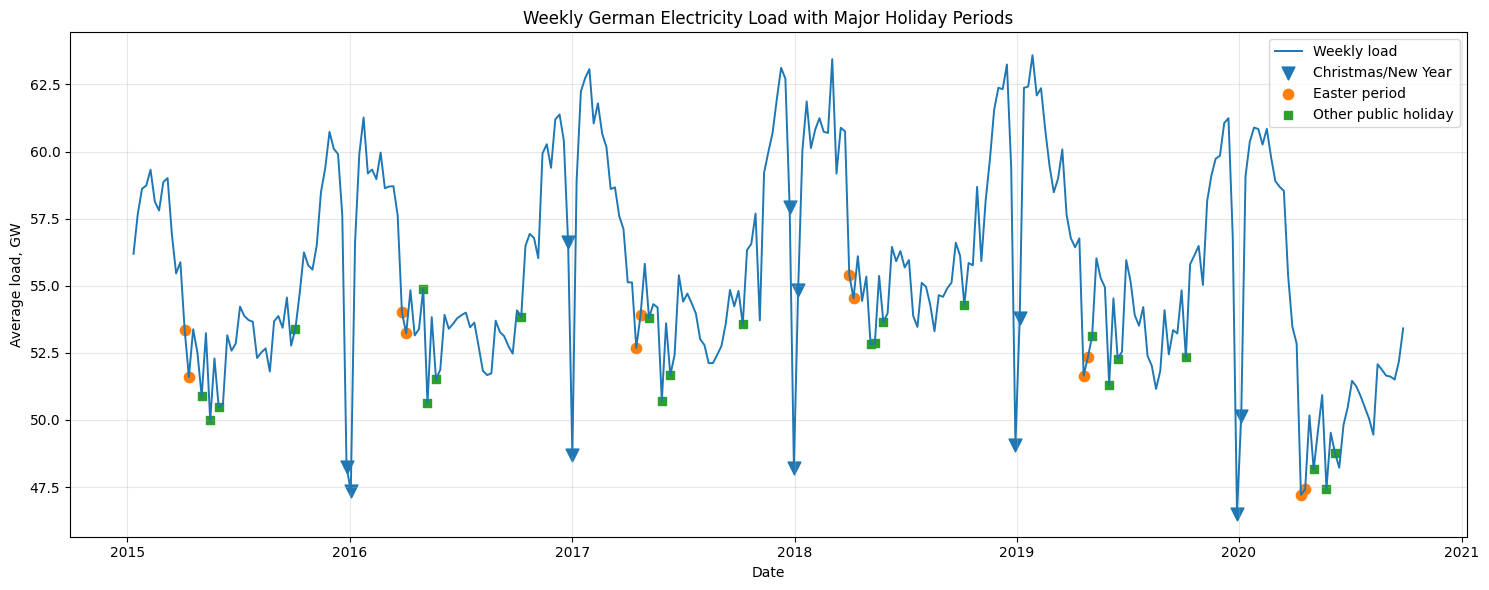

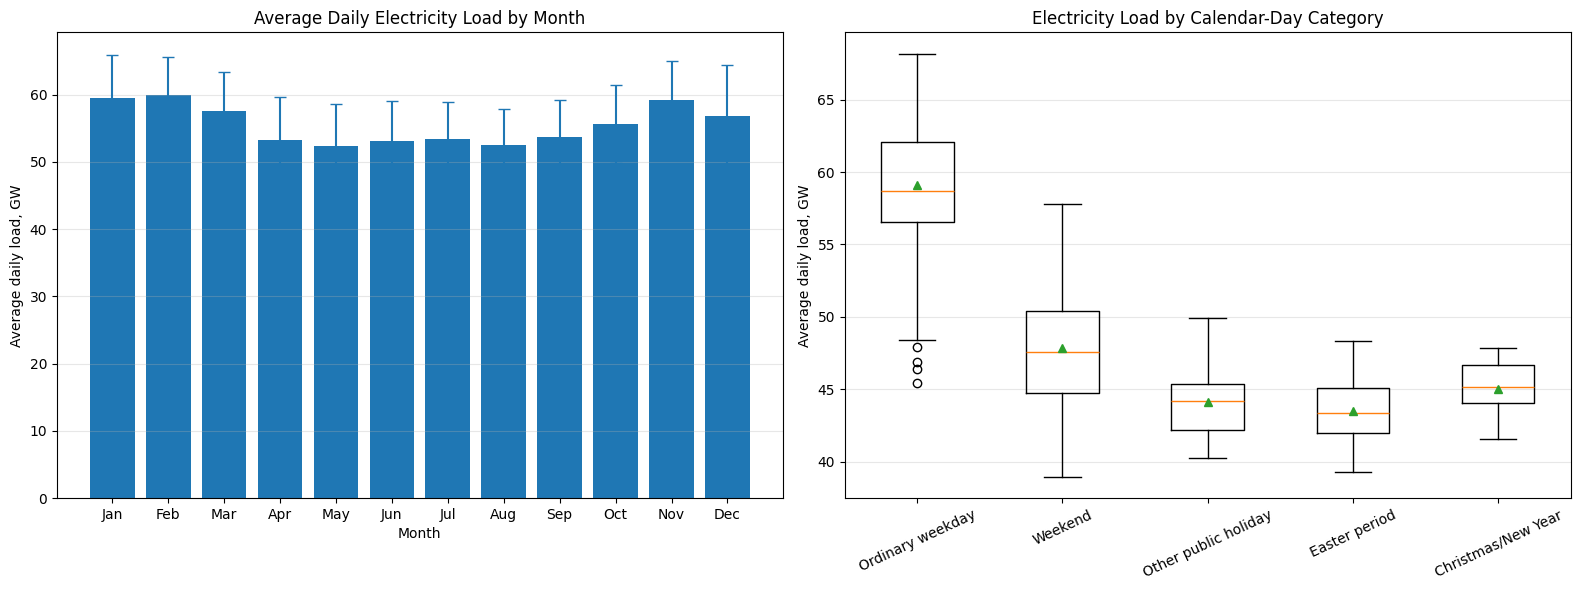

,observations,average_load,median_load,standard_deviation
day_type,,,,
Ordinary weekday,1448,59.089,58.712,3.855
Weekend,585,47.873,47.598,3.828
Other public holiday,23,44.095,44.223,2.323
Easter period,18,43.495,43.375,2.494
Christmas/New Year,26,45.049,45.185,1.838


In [ ]:
# =============================================================================
# CELL 4:  EXPLORATORY ANALYSIS
# =============================================================================

# Weekly load with major holiday periods
figure, axis = plt.subplots(
    figsize=(15, 6)
)

axis.plot(
    weekly_data.index,
    weekly_data["load_gw"],
    linewidth=1.4,
    label="Weekly load"
)

christmas_weeks = weekly_data[
    weekly_data[
        "christmas_new_year"
    ] == 1
]

easter_weeks = weekly_data[
    weekly_data[
        "easter_week"
    ] == 1
]

other_holiday_weeks = weekly_data[
    weekly_data[
        "other_holiday_week"
    ] == 1
]

axis.scatter(
    christmas_weeks.index,
    christmas_weeks["load_gw"],
    marker="v",
    s=85,
    label="Christmas/New Year"
)

axis.scatter(
    easter_weeks.index,
    easter_weeks["load_gw"],
    marker="o",
    s=55,
    label="Easter period"
)

axis.scatter(
    other_holiday_weeks.index,
    other_holiday_weeks[
        "load_gw"
    ],
    marker="s",
    s=35,
    label="Other public holiday"
)

axis.set_title(
    "Weekly German Electricity Load with Major Holiday Periods"
)

axis.set_xlabel("Date")
axis.set_ylabel("Average load, GW")
axis.legend()
axis.grid(alpha=0.3)

plt.tight_layout()

save_figure(
    "01_weekly_load_holidays.png"
)


# Monthly load and day-type comparison
monthly_summary = (
    daily_calendar
    .groupby(
        daily_calendar.index.month
    )["load_gw"]
    .agg(
        average_load="mean",
        standard_deviation="std"
    )
)

month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

day_type_order = [
    "Ordinary weekday",
    "Weekend",
    "Other public holiday",
    "Easter period",
    "Christmas/New Year"
]

day_type_values = [
    daily_calendar.loc[
        daily_calendar[
            "day_type"
        ] == day_type,
        "load_gw"
    ].dropna()
    for day_type in day_type_order
]


figure, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

axes[0].bar(
    month_names,
    monthly_summary[
        "average_load"
    ]
)

axes[0].errorbar(
    month_names,
    monthly_summary[
        "average_load"
    ],
    yerr=monthly_summary[
        "standard_deviation"
    ],
    fmt="none",
    capsize=4
)

axes[0].set_title(
    "Average Daily Electricity Load by Month"
)

axes[0].set_xlabel("Month")
axes[0].set_ylabel("Average daily load, GW")
axes[0].grid(
    axis="y",
    alpha=0.3
)


axes[1].boxplot(
    day_type_values,
    labels=day_type_order,
    showmeans=True
)

axes[1].set_title(
    "Electricity Load by Calendar-Day Category"
)

axes[1].set_ylabel(
    "Average daily load, GW"
)

axes[1].tick_params(
    axis="x",
    rotation=25
)

axes[1].grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

save_figure(
    "02_monthly_and_day_type_load.png"
)


day_type_summary = (
    daily_calendar
    .groupby("day_type")[
        "load_gw"
    ]
    .agg(
        observations="count",
        average_load="mean",
        median_load="median",
        standard_deviation="std"
    )
    .reindex(day_type_order)
)

display(
    day_type_summary.round(3)
)

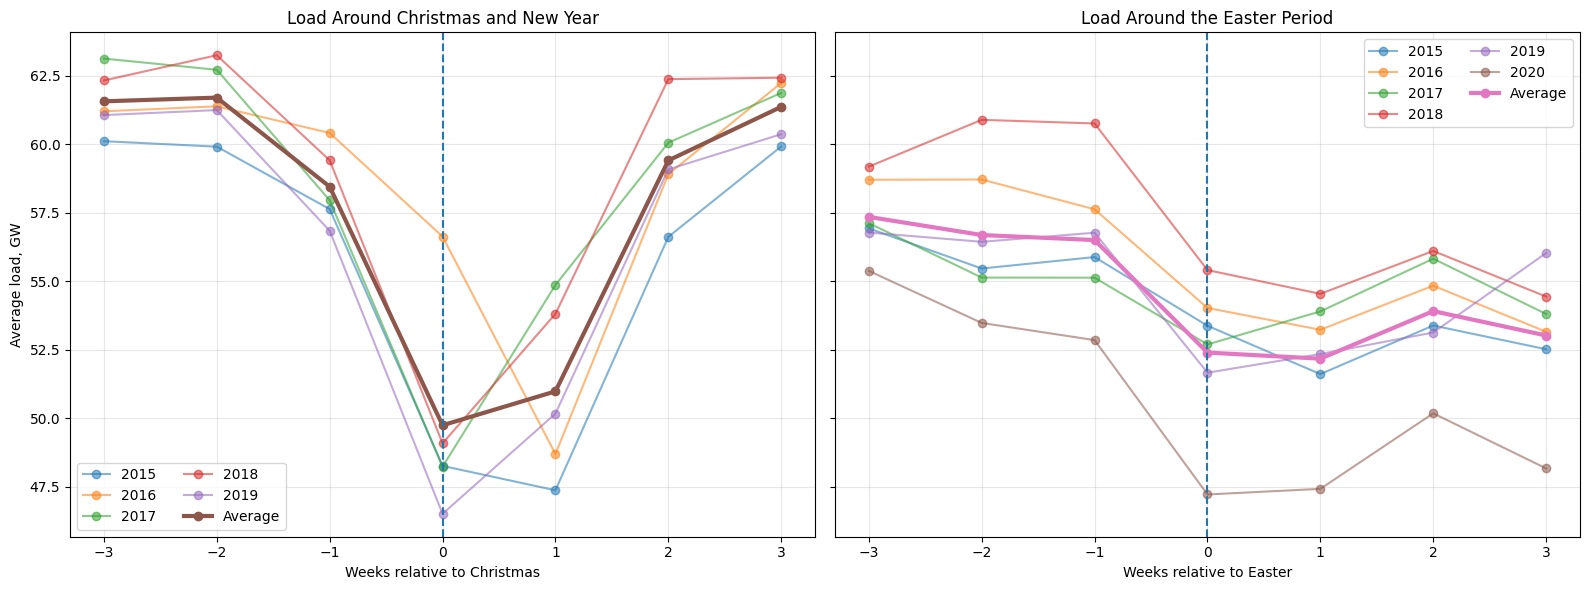

,Christmas average at event week,Christmas average previous week,Easter average at event week,Easter average previous week
0,49.737,58.446,52.391,56.498


In [ ]:
# =============================================================================
# CELL 5: HOLIDAY EVENT-STUDY ANALYSIS
# =============================================================================

def week_ending_sunday(date):
    """Return the Sunday ending the week containing a date."""

    return (
        pd.Timestamp(date)
        .to_period("W-SUN")
        .end_time
        .normalize()
    )


def create_event_window(
    event_dates,
    event_name,
    weeks_before=3,
    weeks_after=3
):
    """Create weekly observations around repeated calendar events."""

    event_rows = []

    for event_date in event_dates:

        event_week = week_ending_sunday(
            event_date
        )

        event_year = pd.Timestamp(
            event_date
        ).year

        for relative_week in range(
            -weeks_before,
            weeks_after + 1
        ):

            observation_date = (
                event_week
                + pd.Timedelta(
                    weeks=relative_week
                )
            )

            if observation_date in weekly_data.index:

                event_rows.append(
                    {
                        "Event": event_name,
                        "Year": event_year,
                        "Relative week": relative_week,

                        "Load": weekly_data.loc[
                            observation_date,
                            "load_gw"
                        ]
                    }
                )

    return pd.DataFrame(
        event_rows
    )


christmas_dates = [
    pd.Timestamp(
        year=year,
        month=12,
        day=25
    )
    for year in range(
        2015,
        2021
    )
]

easter_dates = [
    pd.Timestamp(
        easter(year)
    )
    for year in range(
        2015,
        2021
    )
]


christmas_event = create_event_window(
    christmas_dates,
    "Christmas/New Year"
)

easter_event = create_event_window(
    easter_dates,
    "Easter"
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    sharey=True
)


for year in sorted(
    christmas_event["Year"].unique()
):

    year_data = christmas_event[
        christmas_event["Year"] == year
    ]

    axes[0].plot(
        year_data["Relative week"],
        year_data["Load"],
        marker="o",
        alpha=0.55,
        label=str(year)
    )


christmas_average = (
    christmas_event
    .groupby("Relative week")[
        "Load"
    ]
    .mean()
)

axes[0].plot(
    christmas_average.index,
    christmas_average.values,
    marker="o",
    linewidth=3,
    label="Average"
)

axes[0].axvline(
    0,
    linestyle="--"
)

axes[0].set_title(
    "Load Around Christmas and New Year"
)

axes[0].set_xlabel(
    "Weeks relative to Christmas"
)

axes[0].set_ylabel(
    "Average load, GW"
)

axes[0].legend(
    ncol=2
)

axes[0].grid(
    alpha=0.3
)


for year in sorted(
    easter_event["Year"].unique()
):

    year_data = easter_event[
        easter_event["Year"] == year
    ]

    axes[1].plot(
        year_data["Relative week"],
        year_data["Load"],
        marker="o",
        alpha=0.55,
        label=str(year)
    )


easter_average = (
    easter_event
    .groupby("Relative week")[
        "Load"
    ]
    .mean()
)

axes[1].plot(
    easter_average.index,
    easter_average.values,
    marker="o",
    linewidth=3,
    label="Average"
)

axes[1].axvline(
    0,
    linestyle="--"
)

axes[1].set_title(
    "Load Around the Easter Period"
)

axes[1].set_xlabel(
    "Weeks relative to Easter"
)

axes[1].legend(
    ncol=2
)

axes[1].grid(
    alpha=0.3
)

plt.tight_layout()

save_figure(
    "03_holiday_event_studies.png"
)


event_summary = pd.DataFrame(
    {
        "Christmas average at event week": [
            christmas_average.loc[0]
        ],

        "Christmas average previous week": [
            christmas_average.loc[-1]
        ],

        "Easter average at event week": [
            easter_average.loc[0]
        ],

        "Easter average previous week": [
            easter_average.loc[-1]
        ]
    }
)

display(
    event_summary.round(3)
)

Training period: 2015-01-11 to 2018-09-30
Training weeks: 195
Test period: 2018-10-07 to 2020-09-27
Test weeks: 104


/tmp/ipykernel_1429/2784097432.py:226: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(
/tmp/ipykernel_1429/2784097432.py:226: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(
/tmp/ipykernel_1429/2784097432.py:226: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(
/tmp/ipykernel_1429/2784097432.py:226: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(


,Observations,ADF statistic,ADF p-value,KPSS statistic,KPSS p-value
Series,,,,,
Original weekly load,195,-5.0030,0.0,0.1499,0.1
First difference,194,-5.5708,0.0,0.0406,0.1
Seasonal difference,143,-5.0395,0.0,0.0910,0.1
First and seasonal difference,142,-6.7279,0.0,0.0138,0.1


Lag-52 autocorrelation: 0.873
Initial seasonal difference: 1
Initial ordinary difference: 0


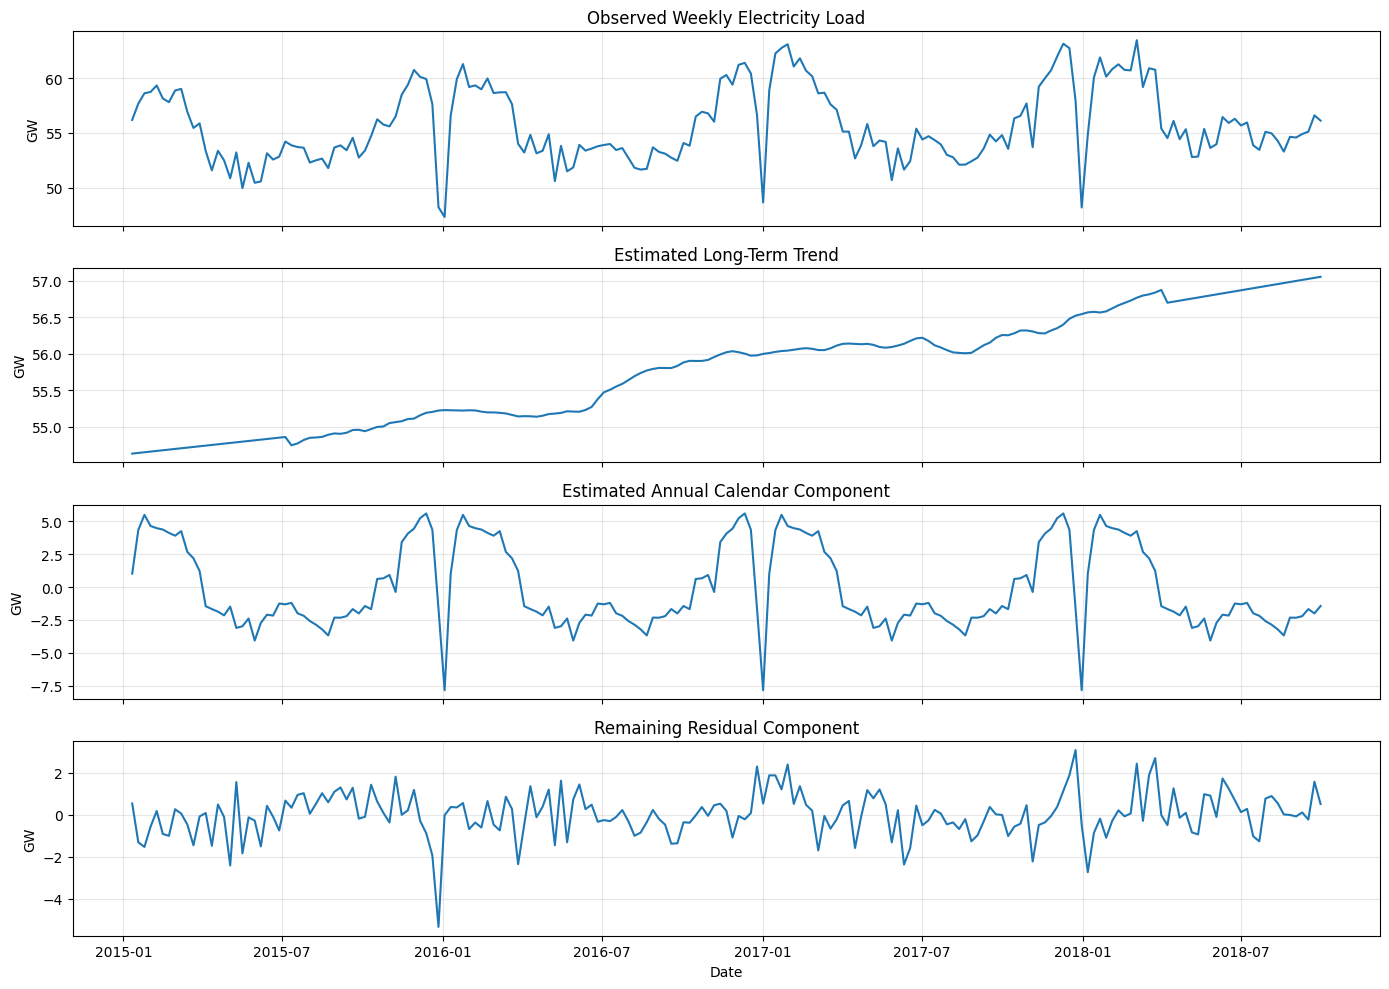

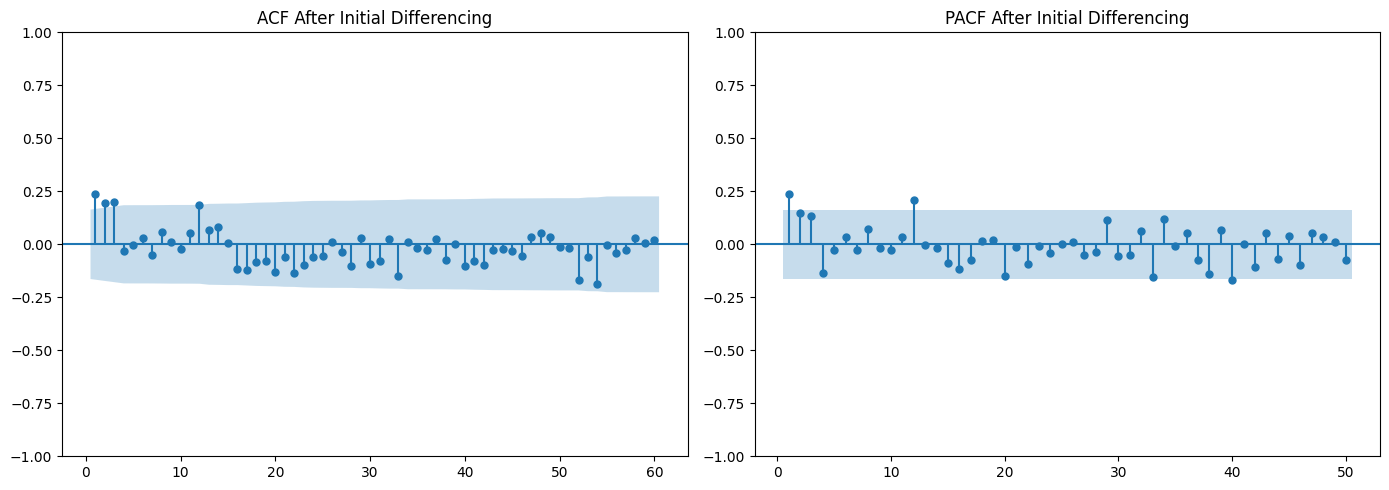

In [ ]:
# =============================================================================
# CELL 6: TRAIN-TEST SPLIT AND TIME-SERIES DIAGNOSTICS
# =============================================================================

train_data = weekly_data.iloc[
    :-TEST_WEEKS
].copy()

test_data = weekly_data.iloc[
    -TEST_WEEKS:
].copy()

y_train = train_data[
    "load_gw"
].copy()

y_test = test_data[
    "load_gw"
].copy()


print(
    "Training period:",
    y_train.index.min().date(),
    "to",
    y_train.index.max().date()
)

print(
    "Training weeks:",
    len(y_train)
)

print(
    "Test period:",
    y_test.index.min().date(),
    "to",
    y_test.index.max().date()
)

print(
    "Test weeks:",
    len(y_test)
)


first_difference = (
    y_train
    .diff()
    .dropna()
)

seasonal_difference = (
    y_train
    .diff(SEASONAL_PERIOD)
    .dropna()
)

combined_difference = (
    y_train
    .diff()
    .diff(SEASONAL_PERIOD)
    .dropna()
)


stationarity_results = pd.DataFrame(
    [
        run_stationarity_tests(
            y_train,
            "Original weekly load"
        ),

        run_stationarity_tests(
            first_difference,
            "First difference"
        ),

        run_stationarity_tests(
            seasonal_difference,
            "Seasonal difference"
        ),

        run_stationarity_tests(
            combined_difference,
            "First and seasonal difference"
        )
    ]
).set_index("Series")

display(
    stationarity_results.round(4)
)


lag_52_autocorrelation = (
    y_train.autocorr(
        lag=SEASONAL_PERIOD
    )
)

INITIAL_D = (
    1
    if abs(
        lag_52_autocorrelation
    ) >= 0.30
    else 0
)

INITIAL_d = (
    1
    if stationarity_results.loc[
        "Original weekly load",
        "ADF p-value"
    ] > 0.05
    else 0
)

print(
    "Lag-52 autocorrelation:",
    round(
        lag_52_autocorrelation,
        3
    )
)

print(
    "Initial seasonal difference:",
    INITIAL_D
)

print(
    "Initial ordinary difference:",
    INITIAL_d
)


decomposition = seasonal_decompose(
    y_train,
    model="additive",
    period=SEASONAL_PERIOD,
    extrapolate_trend="freq"
)

figure, axes = plt.subplots(
    4,
    1,
    figsize=(14, 10),
    sharex=True
)

axes[0].plot(
    decomposition.observed
)

axes[0].set_title(
    "Observed Weekly Electricity Load"
)

axes[1].plot(
    decomposition.trend
)

axes[1].set_title(
    "Estimated Long-Term Trend"
)

axes[2].plot(
    decomposition.seasonal
)

axes[2].set_title(
    "Estimated Annual Calendar Component"
)

axes[3].plot(
    decomposition.resid
)

axes[3].set_title(
    "Remaining Residual Component"
)

axes[3].set_xlabel("Date")

for axis in axes:

    axis.set_ylabel("GW")
    axis.grid(alpha=0.3)

plt.tight_layout()

save_figure(
    "04_calendar_decomposition.png"
)


diagnostic_series = y_train.copy()

if INITIAL_D == 1:

    diagnostic_series = (
        diagnostic_series
        .diff(SEASONAL_PERIOD)
    )

if INITIAL_d == 1:

    diagnostic_series = (
        diagnostic_series
        .diff()
    )

diagnostic_series = (
    diagnostic_series
    .dropna()
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

plot_acf(
    diagnostic_series,
    lags=min(
        60,
        len(diagnostic_series) // 2 - 1
    ),
    zero=False,
    ax=axes[0]
)

axes[0].set_title(
    "ACF After Initial Differencing"
)

plot_pacf(
    diagnostic_series,
    lags=min(
        50,
        len(diagnostic_series) // 2 - 1
    ),
    zero=False,
    method="ywm",
    ax=axes[1]
)

axes[1].set_title(
    "PACF After Initial Differencing"
)

plt.tight_layout()

save_figure(
    "05_calendar_acf_pacf.png"
)

,Model,Status,MAE,RMSE,MASE,sMAPE,Bias
0,Mean,Operational,3.790,4.402,2.805,6.874,0.561
1,Naive,Operational,3.858,4.476,2.856,6.995,0.985
2,Seasonal naive,Operational,2.288,2.988,1.694,4.207,1.748
3,Drift,Operational,3.851,4.466,2.850,6.982,0.966


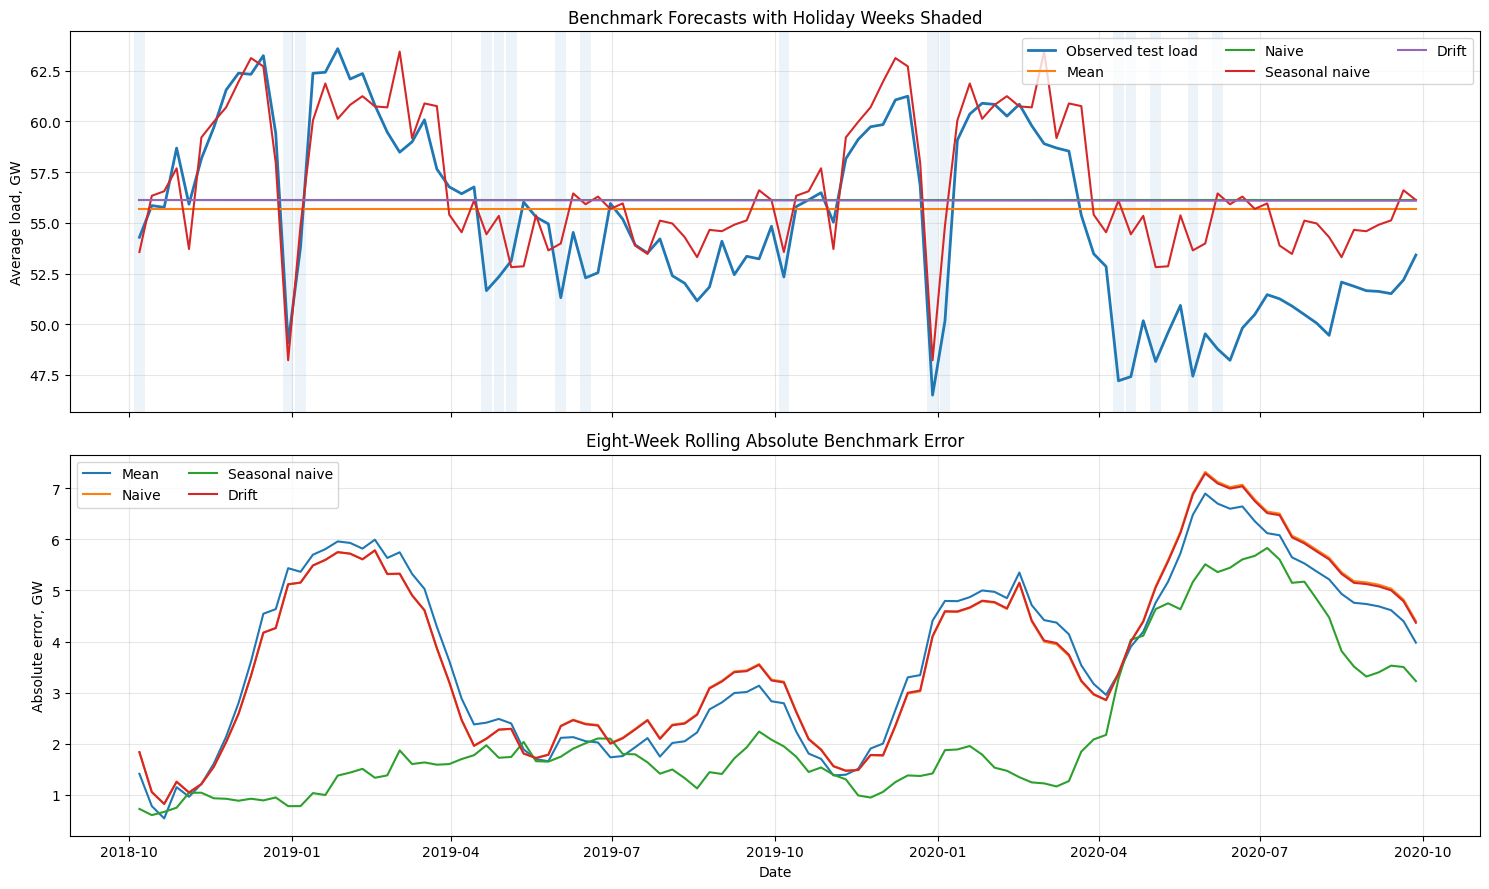

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Best non-seasonal order: (3, 1, 6)
Best seasonal order: (1, 1, 1, 52)
Search time in minutes: 15.56


,lb_stat,lb_pvalue
10,8.3993,0.5899
26,11.7302,0.9926
49,21.9252,0.9997


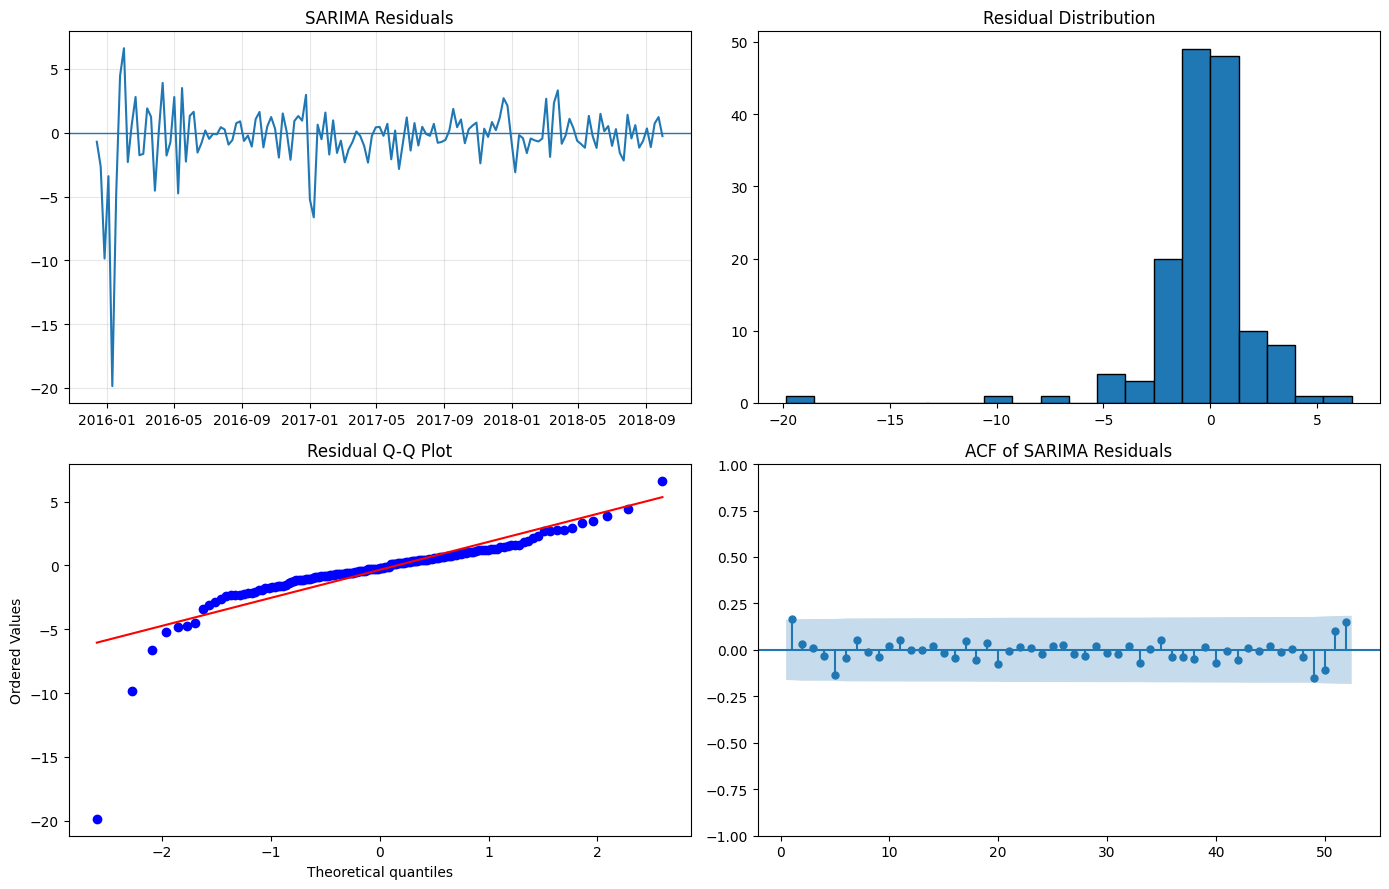

In [ ]:
# =============================================================================
# CELL 7: BENCHMARK FORECASTS AND LOAD-ONLY SARIMA
# =============================================================================

results = []
forecast_store = {}


# Benchmark forecasts
forecast_horizon = len(
    y_test
)

mean_forecast = pd.Series(
    y_train.mean(),
    index=y_test.index
)

naive_forecast = pd.Series(
    y_train.iloc[-1],
    index=y_test.index
)

seasonal_pattern = (
    y_train
    .iloc[-SEASONAL_PERIOD:]
    .to_numpy()
)

seasonal_naive_forecast = pd.Series(
    np.resize(
        seasonal_pattern,
        forecast_horizon
    ),
    index=y_test.index
)

drift_slope = (
    y_train.iloc[-1]
    - y_train.iloc[0]
) / (
    len(y_train) - 1
)

drift_forecast = pd.Series(
    y_train.iloc[-1]
    + drift_slope
    * np.arange(
        1,
        forecast_horizon + 1
    ),
    index=y_test.index
)


benchmark_forecasts = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal naive": seasonal_naive_forecast,
    "Drift": drift_forecast
}


for model_name, prediction in benchmark_forecasts.items():

    results.append(
        evaluate_forecast(
            model_name,
            y_test,
            prediction,
            y_train,
            "Operational"
        )
    )

    forecast_store[
        model_name
    ] = prediction


benchmark_results = pd.DataFrame(
    results
)

display(
    benchmark_results.round(3)
)


figure, axes = plt.subplots(
    2,
    1,
    figsize=(15, 9),
    sharex=True
)

axes[0].plot(
    y_test.index,
    y_test,
    linewidth=2,
    label="Observed test load"
)

for model_name, prediction in benchmark_forecasts.items():

    axes[0].plot(
        y_test.index,
        prediction,
        label=model_name
    )

shade_holiday_weeks(
    axes[0],
    test_data
)

axes[0].set_title(
    "Benchmark Forecasts with Holiday Weeks Shaded"
)

axes[0].set_ylabel(
    "Average load, GW"
)

axes[0].legend(
    ncol=3
)

axes[0].grid(
    alpha=0.3
)


for model_name, prediction in benchmark_forecasts.items():

    rolling_error = (
        prediction - y_test
    ).abs().rolling(
        8,
        min_periods=1
    ).mean()

    axes[1].plot(
        rolling_error.index,
        rolling_error,
        label=model_name
    )

axes[1].set_title(
    "Eight-Week Rolling Absolute Benchmark Error"
)

axes[1].set_xlabel("Date")
axes[1].set_ylabel("Absolute error, GW")
axes[1].legend(ncol=2)
axes[1].grid(alpha=0.3)

plt.tight_layout()

save_figure(
    "06_calendar_benchmarks.png"
)


def fit_sarima_model(
    order,
    seasonal_order,
    max_iterations=60
):
    """Fit one SARIMA specification."""

    trend_setting = (
        "c"
        if (
            order[1] == 0
            and seasonal_order[1] == 0
        )
        else "n"
    )

    model = SARIMAX(
        y_train,
        order=order,
        seasonal_order=seasonal_order,
        trend=trend_setting,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(
        disp=False,
        maxiter=max_iterations
    )

    return fitted_model


# Full maximum-likelihood search over 147 p-d-q combinations
search_rows = []
search_start = time.time()

for p, d, q in itertools.product(
    range(7),
    range(3),
    range(7)
):

    order = (
        p,
        d,
        q
    )

    seasonal_order = (
        0,
        INITIAL_D,
        0,
        SEASONAL_PERIOD
    )

    try:

        fitted = fit_sarima_model(
            order,
            seasonal_order,
            max_iterations=50
        )

        search_rows.append(
            {
                "p": p,
                "d": d,
                "q": q,

                "AIC": fitted.aic,
                "BIC": fitted.bic,

                "Converged": bool(
                    fitted.mle_retvals.get(
                        "converged",
                        True
                    )
                )
            }
        )

    except Exception:

        search_rows.append(
            {
                "p": p,
                "d": d,
                "q": q,
                "AIC": np.nan,
                "BIC": np.nan,
                "Converged": False
            }
        )


sarima_search = pd.DataFrame(
    search_rows
)

valid_search = sarima_search[
    sarima_search[
        "Converged"
    ]
    &
    sarima_search[
        "AIC"
    ].notna()
].sort_values(
    "AIC"
)

if valid_search.empty:

    valid_search = sarima_search[
        sarima_search[
            "AIC"
        ].notna()
    ].sort_values(
        "AIC"
    )


best_order = tuple(
    valid_search.iloc[0][
        ["p", "d", "q"]
    ]
    .astype(int)
    .tolist()
)


# Seasonal-order comparison
seasonal_rows = []

for P, D, Q in itertools.product(
    [0, 1],
    [0, 1],
    [0, 1]
):

    seasonal_order = (
        P,
        D,
        Q,
        SEASONAL_PERIOD
    )

    try:

        fitted = fit_sarima_model(
            best_order,
            seasonal_order,
            max_iterations=80
        )

        seasonal_rows.append(
            {
                "P": P,
                "D": D,
                "Q": Q,

                "AIC": fitted.aic,
                "BIC": fitted.bic,

                "Converged": bool(
                    fitted.mle_retvals.get(
                        "converged",
                        True
                    )
                )
            }
        )

    except Exception:

        seasonal_rows.append(
            {
                "P": P,
                "D": D,
                "Q": Q,
                "AIC": np.nan,
                "BIC": np.nan,
                "Converged": False
            }
        )


seasonal_search = pd.DataFrame(
    seasonal_rows
)

valid_seasonal = seasonal_search[
    seasonal_search[
        "Converged"
    ]
    &
    seasonal_search[
        "AIC"
    ].notna()
].sort_values(
    "AIC"
)

if valid_seasonal.empty:

    valid_seasonal = seasonal_search[
        seasonal_search[
            "AIC"
        ].notna()
    ].sort_values(
        "AIC"
    )


best_seasonal_order = tuple(
    valid_seasonal.iloc[0][
        ["P", "D", "Q"]
    ]
    .astype(int)
    .tolist()
) + (
    SEASONAL_PERIOD,
)


sarima_fit = fit_sarima_model(
    best_order,
    best_seasonal_order,
    max_iterations=120
)


print(
    "Best non-seasonal order:",
    best_order
)

print(
    "Best seasonal order:",
    best_seasonal_order
)

print(
    "Search time in minutes:",
    round(
        (
            time.time()
            - search_start
        ) / 60,
        2
    )
)


sarima_search.to_csv(
    TABLE_DIR
    / "sarima_pdq_search.csv",
    index=False
)

seasonal_search.to_csv(
    TABLE_DIR
    / "sarima_seasonal_search.csv",
    index=False
)


sarima_forecast_object = (
    sarima_fit.get_forecast(
        steps=len(y_test)
    )
)

sarima_forecast = (
    sarima_forecast_object
    .predicted_mean
)

sarima_forecast.index = y_test.index

sarima_interval_95 = (
    sarima_forecast_object
    .conf_int(alpha=0.05)
)

sarima_interval_95.index = y_test.index


sarima_metrics = evaluate_forecast(
    "SARIMA",
    y_test,
    sarima_forecast,
    y_train,
    "Operational"
)

sarima_metrics[
    "Interval coverage"
] = float(
    (
        (
            y_test
            >= sarima_interval_95.iloc[
                :, 0
            ]
        )
        &
        (
            y_test
            <= sarima_interval_95.iloc[
                :, 1
            ]
        )
    ).mean()
)

results.append(
    sarima_metrics
)

forecast_store[
    "SARIMA"
] = sarima_forecast


sarima_residuals = pd.Series(
    sarima_fit.resid,
    index=y_train.index
)

sarima_residuals = (
    sarima_residuals
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .dropna()
)

sarima_residuals = (
    sarima_residuals.iloc[
        min(
            SEASONAL_PERIOD,
            len(sarima_residuals) // 4
        ):
    ]
)


ljung_box_results = acorr_ljungbox(
    sarima_residuals,
    lags=[
        10,
        26,
        min(
            52,
            len(sarima_residuals) // 3
        )
    ],
    return_df=True
)

display(
    ljung_box_results.round(4)
)


figure, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9)
)

axes[0, 0].plot(
    sarima_residuals.index,
    sarima_residuals
)

axes[0, 0].axhline(
    0,
    linewidth=1
)

axes[0, 0].set_title(
    "SARIMA Residuals"
)

axes[0, 0].grid(alpha=0.3)


axes[0, 1].hist(
    sarima_residuals,
    bins=20,
    edgecolor="black"
)

axes[0, 1].set_title(
    "Residual Distribution"
)


stats.probplot(
    sarima_residuals,
    dist="norm",
    plot=axes[1, 0]
)

axes[1, 0].set_title(
    "Residual Q-Q Plot"
)


plot_acf(
    sarima_residuals,
    lags=min(
        52,
        len(sarima_residuals) // 2 - 1
    ),
    zero=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "ACF of SARIMA Residuals"
)

plt.tight_layout()

save_figure(
    "07_sarima_residuals.png"
)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Model,Features,AIC,BIC,MAE,RMSE,sMAPE,Coverage
1,SARIMAX weather-only,"heating_degree, cooling_degree",284.524,318.388,3.036,3.842,5.539,0.538
2,SARIMAX full,"holiday_days, christmas_new_year, easter_week,...",243.777,296.992,3.339,4.043,6.046,0.327
0,SARIMAX calendar-only,"holiday_days, christmas_new_year, easter_week,...",260.290,308.666,4.133,4.880,7.379,0.404


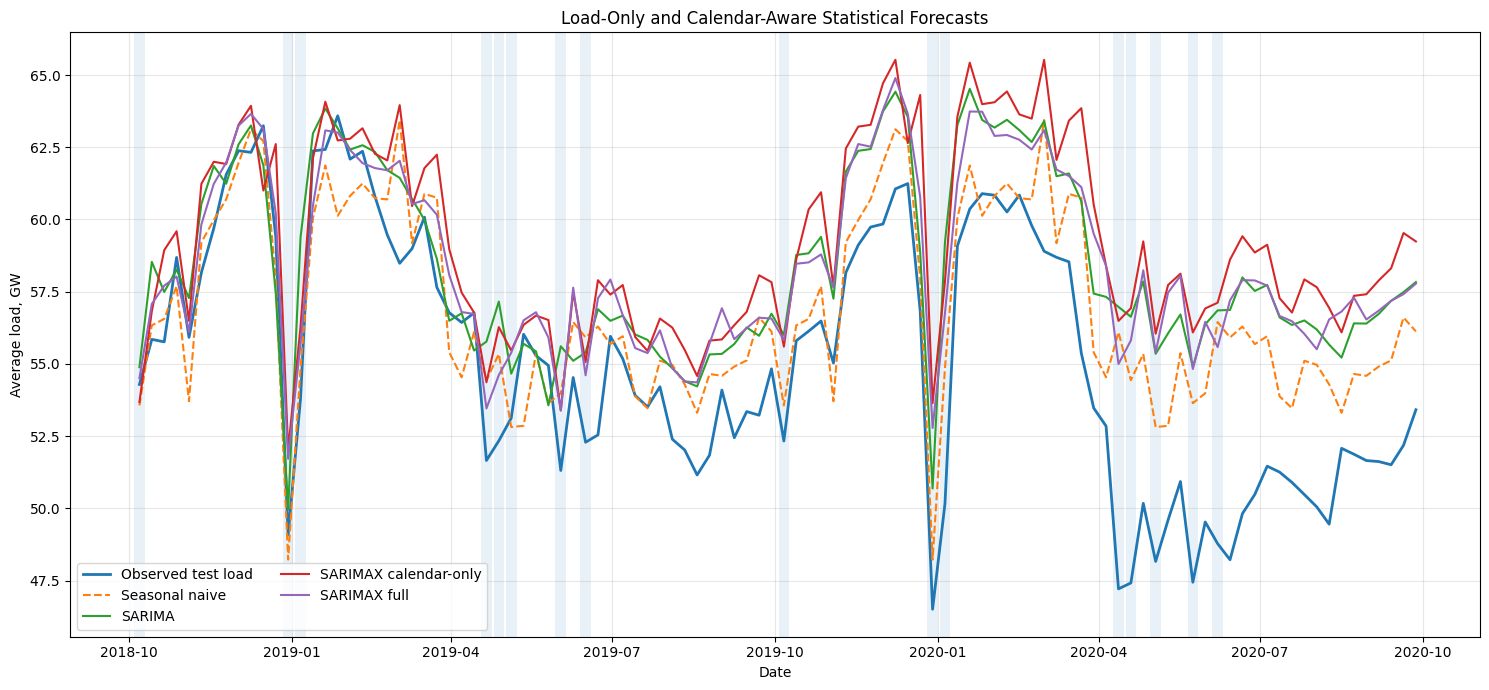

In [ ]:
# =============================================================================
# CELL 8: CALENDAR-AWARE SARIMAX MODELS
# =============================================================================

calendar_features = [
    "holiday_days",
    "christmas_new_year",
    "easter_week",
    "pre_christmas_week",
    "post_christmas_week",
    "pre_easter_week",
    "post_easter_week",
    "working_days"
]

weather_features = [
    "heating_degree",
    "cooling_degree"
]

sarimax_feature_sets = {
    "SARIMAX calendar-only": (
        calendar_features
    ),

    "SARIMAX weather-only": (
        weather_features
    ),

    "SARIMAX full": (
        calendar_features
        + weather_features
    )
}


sarimax_outputs = {}
sarimax_comparison_rows = []


for model_name, feature_columns in sarimax_feature_sets.items():

    X_train = train_data[
        feature_columns
    ].astype(float)

    X_test = test_data[
        feature_columns
    ].astype(float)

    scaler = StandardScaler()

    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(
            X_train
        ),
        index=X_train.index,
        columns=feature_columns
    )

    X_test_scaled = pd.DataFrame(
        scaler.transform(
            X_test
        ),
        index=X_test.index,
        columns=feature_columns
    )

    trend_setting = (
        "c"
        if (
            best_order[1] == 0
            and best_seasonal_order[1] == 0
        )
        else "n"
    )

    model = SARIMAX(
        y_train,
        exog=X_train_scaled,
        order=best_order,
        seasonal_order=best_seasonal_order,
        trend=trend_setting,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(
        disp=False,
        maxiter=120
    )

    forecast_object = fitted.get_forecast(
        steps=len(y_test),
        exog=X_test_scaled
    )

    prediction = (
        forecast_object
        .predicted_mean
    )

    prediction.index = y_test.index

    interval_95 = (
        forecast_object
        .conf_int(alpha=0.05)
    )

    interval_95.index = y_test.index

    forecast_status = (
        "Operational"
        if model_name
        == "SARIMAX calendar-only"
        else "Conditional"
    )

    metrics = evaluate_forecast(
        model_name,
        y_test,
        prediction,
        y_train,
        forecast_status
    )

    metrics[
        "Interval coverage"
    ] = float(
        (
            (
                y_test
                >= interval_95.iloc[
                    :, 0
                ]
            )
            &
            (
                y_test
                <= interval_95.iloc[
                    :, 1
                ]
            )
        ).mean()
    )

    results.append(
        metrics
    )

    forecast_store[
        model_name
    ] = prediction

    sarimax_outputs[
        model_name
    ] = {
        "fit": fitted,
        "prediction": prediction,
        "interval": interval_95,
        "features": feature_columns
    }

    sarimax_comparison_rows.append(
        {
            "Model": model_name,
            "Features": ", ".join(
                feature_columns
            ),
            "AIC": fitted.aic,
            "BIC": fitted.bic,
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "sMAPE": metrics["sMAPE"],
            "Coverage": metrics[
                "Interval coverage"
            ]
        }
    )


sarimax_comparison = (
    pd.DataFrame(
        sarimax_comparison_rows
    )
    .sort_values("RMSE")
)

display(
    sarimax_comparison.round(3)
)

sarimax_comparison.to_csv(
    TABLE_DIR
    / "calendar_sarimax_comparison.csv",
    index=False
)


figure, axis = plt.subplots(
    figsize=(15, 7)
)

axis.plot(
    y_test.index,
    y_test,
    linewidth=2,
    label="Observed test load"
)

axis.plot(
    y_test.index,
    seasonal_naive_forecast,
    linestyle="--",
    label="Seasonal naive"
)

axis.plot(
    y_test.index,
    sarima_forecast,
    label="SARIMA"
)

axis.plot(
    y_test.index,
    forecast_store[
        "SARIMAX calendar-only"
    ],
    label="SARIMAX calendar-only"
)

axis.plot(
    y_test.index,
    forecast_store[
        "SARIMAX full"
    ],
    label="SARIMAX full"
)

shade_holiday_weeks(
    axis,
    test_data,
    alpha=0.10
)

axis.set_title(
    "Load-Only and Calendar-Aware Statistical Forecasts"
)

axis.set_xlabel("Date")
axis.set_ylabel("Average load, GW")
axis.legend(ncol=2)
axis.grid(alpha=0.3)

plt.tight_layout()

save_figure(
    "08_calendar_sarimax_forecasts.png"
)

,Candidate,Validation RMSE,n_estimators,learning_rate,max_depth,min_samples_leaf,subsample
Variant,,,,,,,
GB calendar-only,1,1.6050,150,0.03,2,5,0.9
GB full,1,1.8548,150,0.03,2,5,0.9
GB load-only,1,2.0023,150,0.03,2,5,0.9
GB weather-only,1,2.0079,150,0.03,2,5,0.9


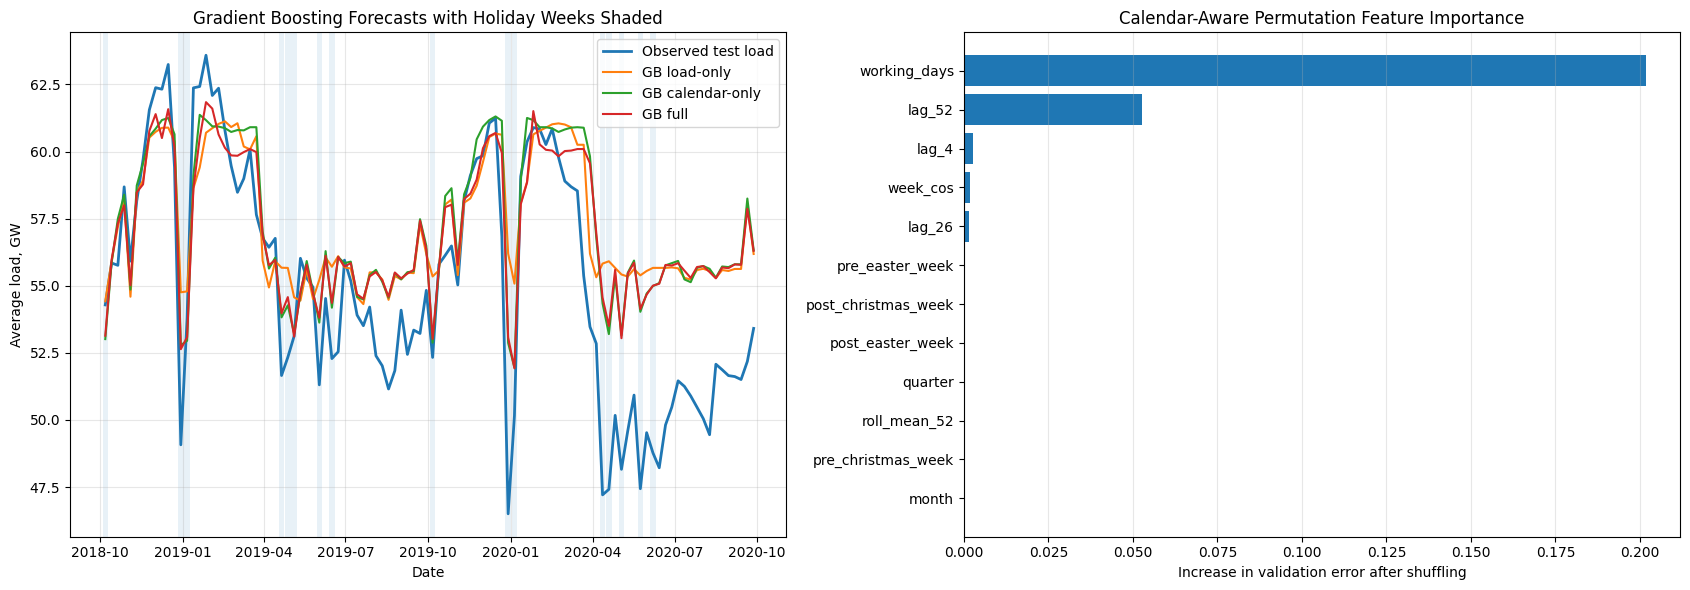

In [ ]:
# =============================================================================
# CELL 9: CALENDAR-AWARE GRADIENT BOOSTING
# =============================================================================

LOAD_LAGS = [
    1,
    2,
    4,
    8,
    13,
    26,
    52
]

calendar_gb_features = [
    "month",
    "quarter",
    "week_of_year",
    "week_sin",
    "week_cos",
    "holiday_days",
    "christmas_new_year",
    "easter_week",
    "pre_christmas_week",
    "post_christmas_week",
    "pre_easter_week",
    "post_easter_week",
    "working_days"
]

weather_gb_features = [
    "temp_mean",
    "heating_degree",
    "cooling_degree",
    "temp_lag_1",
    "temp_lag_2"
]

GB_VARIANTS = {
    "GB load-only": [],

    "GB calendar-only": (
        calendar_gb_features
    ),

    "GB weather-only": (
        weather_gb_features
    ),

    "GB full": (
        calendar_gb_features
        + weather_gb_features
    )
}


GB_PARAMETER_CANDIDATES = [
    {
        "n_estimators": 150,
        "learning_rate": 0.03,
        "max_depth": 2,
        "min_samples_leaf": 5,
        "subsample": 0.90
    },

    {
        "n_estimators": 250,
        "learning_rate": 0.03,
        "max_depth": 2,
        "min_samples_leaf": 4,
        "subsample": 0.85
    },

    {
        "n_estimators": 180,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_samples_leaf": 5,
        "subsample": 0.90
    },

    {
        "n_estimators": 200,
        "learning_rate": 0.04,
        "max_depth": 3,
        "min_samples_leaf": 5,
        "subsample": 0.85
    }
]


def create_gb_training_table(
    load_series,
    full_frame,
    external_features
):
    """Create lagged load and external predictors."""

    table = pd.DataFrame(
        index=load_series.index
    )

    table["target"] = load_series

    for lag in LOAD_LAGS:

        table[
            f"lag_{lag}"
        ] = load_series.shift(lag)

    table["roll_mean_4"] = (
        load_series
        .shift(1)
        .rolling(4)
        .mean()
    )

    table["roll_mean_13"] = (
        load_series
        .shift(1)
        .rolling(13)
        .mean()
    )

    table["roll_mean_52"] = (
        load_series
        .shift(1)
        .rolling(52)
        .mean()
    )

    table["roll_std_13"] = (
        load_series
        .shift(1)
        .rolling(13)
        .std()
    )

    table["time_index"] = np.arange(
        len(table)
    )

    for column in external_features:

        table[column] = full_frame.loc[
            table.index,
            column
        ]

    return table.dropna()


def create_future_gb_row(
    forecast_date,
    load_history,
    full_frame,
    external_features,
    time_origin
):
    """Create predictors for one recursive forecast week."""

    load_history = (
        pd.Series(
            load_history
        )
        .sort_index()
    )

    row = {}

    for lag in LOAD_LAGS:

        row[
            f"lag_{lag}"
        ] = load_history.iloc[-lag]

    row["roll_mean_4"] = (
        load_history
        .iloc[-4:]
        .mean()
    )

    row["roll_mean_13"] = (
        load_history
        .iloc[-13:]
        .mean()
    )

    row["roll_mean_52"] = (
        load_history
        .iloc[-52:]
        .mean()
    )

    row["roll_std_13"] = (
        load_history
        .iloc[-13:]
        .std()
    )

    row["time_index"] = int(
        (
            forecast_date
            - time_origin
        ).days / 7
    )

    for column in external_features:

        row[column] = full_frame.loc[
            forecast_date,
            column
        ]

    return pd.DataFrame(
        [row],
        index=[forecast_date]
    )


def recursive_gb_forecast(
    model,
    initial_history,
    forecast_index,
    full_frame,
    external_features,
    feature_columns
):
    """Generate a recursive multi-week forecast."""

    history = initial_history.copy()

    predictions = []
    feature_rows = []

    time_origin = history.index[0]

    for forecast_date in forecast_index:

        future_row = create_future_gb_row(
            forecast_date,
            history,
            full_frame,
            external_features,
            time_origin
        )

        future_row = future_row.reindex(
            columns=feature_columns
        )

        prediction = float(
            model.predict(
                future_row
            )[0]
        )

        predictions.append(
            prediction
        )

        feature_rows.append(
            future_row
        )

        history.loc[
            forecast_date
        ] = prediction

    return (
        pd.Series(
            predictions,
            index=forecast_index
        ),

        pd.concat(
            feature_rows
        )
    )


validation_weeks = 26

subtraining_load = y_train.iloc[
    :-validation_weeks
]

validation_load = y_train.iloc[
    -validation_weeks:
]


gb_tuning_rows = []
gb_outputs = {}

calendar_importance_package = None


for variant_name, external_features in GB_VARIANTS.items():

    subtraining_table = (
        create_gb_training_table(
            subtraining_load,
            weekly_data,
            external_features
        )
    )

    X_subtraining = (
        subtraining_table
        .drop(columns="target")
    )

    y_subtraining = (
        subtraining_table["target"]
    )

    candidate_results = []

    for candidate_number, parameters in enumerate(
        GB_PARAMETER_CANDIDATES,
        start=1
    ):

        model = GradientBoostingRegressor(
            random_state=RANDOM_STATE,
            **parameters
        )

        model.fit(
            X_subtraining,
            y_subtraining
        )

        (
            validation_prediction,
            validation_features
        ) = recursive_gb_forecast(
            model,
            subtraining_load,
            validation_load.index,
            weekly_data,
            external_features,
            X_subtraining.columns
        )

        validation_rmse = calculate_rmse(
            validation_load,
            validation_prediction
        )

        candidate_results.append(
            (
                validation_rmse,
                parameters,
                model,
                validation_features
            )
        )

        gb_tuning_rows.append(
            {
                "Variant": variant_name,
                "Candidate": candidate_number,
                "Validation RMSE": validation_rmse,
                **parameters
            }
        )

    candidate_results.sort(
        key=lambda item: item[0]
    )

    (
        best_validation_rmse,
        best_parameters,
        best_validation_model,
        best_validation_features
    ) = candidate_results[0]


    complete_training_table = (
        create_gb_training_table(
            y_train,
            weekly_data,
            external_features
        )
    )

    X_complete = (
        complete_training_table
        .drop(columns="target")
    )

    y_complete = (
        complete_training_table[
            "target"
        ]
    )

    final_model = GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        **best_parameters
    )

    final_model.fit(
        X_complete,
        y_complete
    )

    (
        test_prediction,
        test_features
    ) = recursive_gb_forecast(
        final_model,
        y_train,
        y_test.index,
        weekly_data,
        external_features,
        X_complete.columns
    )

    forecast_status = (
        "Operational"
        if variant_name in [
            "GB load-only",
            "GB calendar-only"
        ]
        else "Conditional"
    )

    metrics = evaluate_forecast(
        variant_name,
        y_test,
        test_prediction,
        y_train,
        forecast_status
    )

    results.append(
        metrics
    )

    forecast_store[
        variant_name
    ] = test_prediction

    gb_outputs[
        variant_name
    ] = {
        "model": final_model,
        "parameters": best_parameters,
        "validation_rmse": best_validation_rmse,
        "features": X_complete.columns.tolist()
    }

    if variant_name == "GB calendar-only":

        calendar_importance_package = {
            "model": best_validation_model,
            "X": best_validation_features,
            "y": validation_load
        }


gb_tuning_results = pd.DataFrame(
    gb_tuning_rows
)

display(
    gb_tuning_results
    .sort_values(
        [
            "Variant",
            "Validation RMSE"
        ]
    )
    .groupby("Variant")
    .first()
    .round(4)
)


importance_result = permutation_importance(
    calendar_importance_package[
        "model"
    ],
    calendar_importance_package[
        "X"
    ],
    calendar_importance_package[
        "y"
    ],
    scoring="neg_root_mean_squared_error",
    n_repeats=20,
    random_state=RANDOM_STATE
)

calendar_importance = pd.DataFrame(
    {
        "Feature": calendar_importance_package[
            "X"
        ].columns,

        "Importance": importance_result
        .importances_mean,

        "Standard deviation": importance_result
        .importances_std
    }
).sort_values(
    "Importance",
    ascending=False
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(17, 6)
)

axes[0].plot(
    y_test.index,
    y_test,
    linewidth=2,
    label="Observed test load"
)

for model_name in [
    "GB load-only",
    "GB calendar-only",
    "GB full"
]:

    axes[0].plot(
        y_test.index,
        forecast_store[
            model_name
        ],
        label=model_name
    )

shade_holiday_weeks(
    axes[0],
    test_data,
    alpha=0.10
)

axes[0].set_title(
    "Gradient Boosting Forecasts with Holiday Weeks Shaded"
)

axes[0].set_xlabel("Date")
axes[0].set_ylabel("Average load, GW")
axes[0].legend()
axes[0].grid(alpha=0.3)


top_features = (
    calendar_importance
    .head(12)
    .sort_values("Importance")
)

axes[1].barh(
    top_features["Feature"],
    top_features["Importance"]
)

axes[1].set_title(
    "Calendar-Aware Permutation Feature Importance"
)

axes[1].set_xlabel(
    "Increase in validation error after shuffling"
)

axes[1].grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

save_figure(
    "09_calendar_gradient_boosting.png"
)


gb_tuning_results.to_csv(
    TABLE_DIR
    / "calendar_gb_tuning.csv",
    index=False
)

calendar_importance.to_csv(
    TABLE_DIR
    / "calendar_feature_importance.csv",
    index=False
)

,Architecture,First units,Second units,Dropout,Learning rate,Validation RMSE,Epochs
1,Two layers,48,24.0,0.15,0.001,5.2749,8
0,One layer,32,NaN,0.10,0.001,5.3322,8


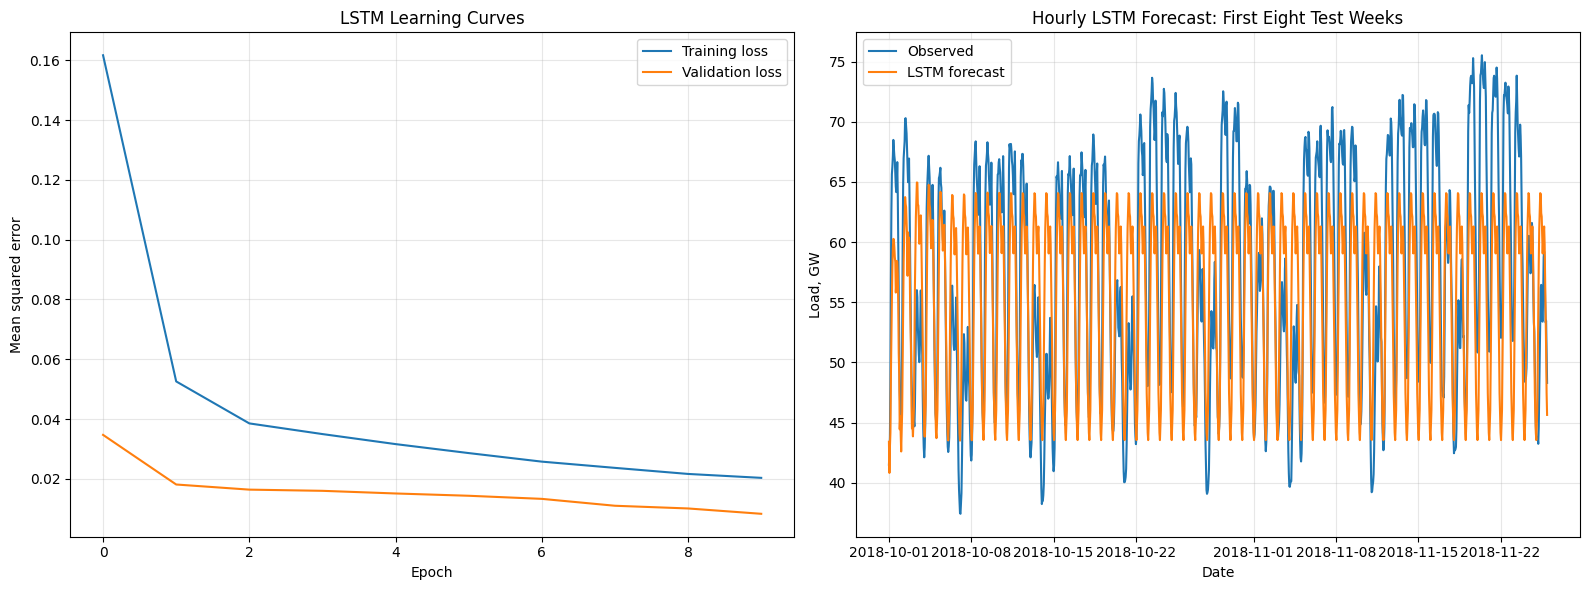

,Model,Status,MAE,RMSE,MASE,sMAPE,Bias,Interval coverage
0,Seasonal naive,Operational,2.288,2.988,1.694,4.207,1.748,NaN
1,GB full,Conditional,2.406,3.144,1.781,4.446,1.831,NaN
2,GB calendar-only,Operational,2.470,3.196,1.828,4.548,2.044,NaN
3,GB load-only,Operational,2.701,3.504,1.999,4.972,2.067,NaN
4,GB weather-only,Conditional,2.709,3.507,2.005,4.992,1.965,NaN
5,SARIMAX weather-only,Conditional,3.036,3.842,2.247,5.539,2.889,0.538
6,SARIMAX full,Conditional,3.339,4.043,2.472,6.046,3.268,0.327
7,SARIMA,Operational,3.344,4.080,2.475,6.049,3.192,0.712
8,LSTM aggregated weekly,Operational,3.783,4.397,2.800,6.862,0.522,NaN
9,Mean,Operational,3.790,4.402,2.805,6.874,0.561,NaN


,Model,Holiday MAE,Holiday RMSE,Holiday bias,Non-holiday MAE,Non-holiday RMSE,Christmas RMSE,Easter RMSE
0,GB calendar-only,3.355,4.100,3.088,2.309,3.002,3.817,4.815
1,GB full,3.428,4.188,3.192,2.221,2.914,3.856,5.035
2,Seasonal naive,3.569,4.425,3.333,2.056,2.644,2.591,6.021
3,SARIMAX full,4.342,5.082,4.342,3.157,3.825,4.836,5.905
4,GB weather-only,4.950,5.633,4.950,2.301,2.961,5.936,6.429
5,SARIMAX weather-only,4.930,5.693,4.930,2.692,3.399,5.319,6.914
6,GB load-only,4.985,5.737,4.985,2.286,2.920,6.152,6.588
7,LSTM aggregated weekly,5.278,5.853,5.278,3.512,4.076,6.345,6.454
8,Mean,5.333,5.890,5.333,3.509,4.074,6.378,6.488
9,SARIMAX calendar-only,5.101,5.913,5.025,3.957,4.668,5.588,7.059


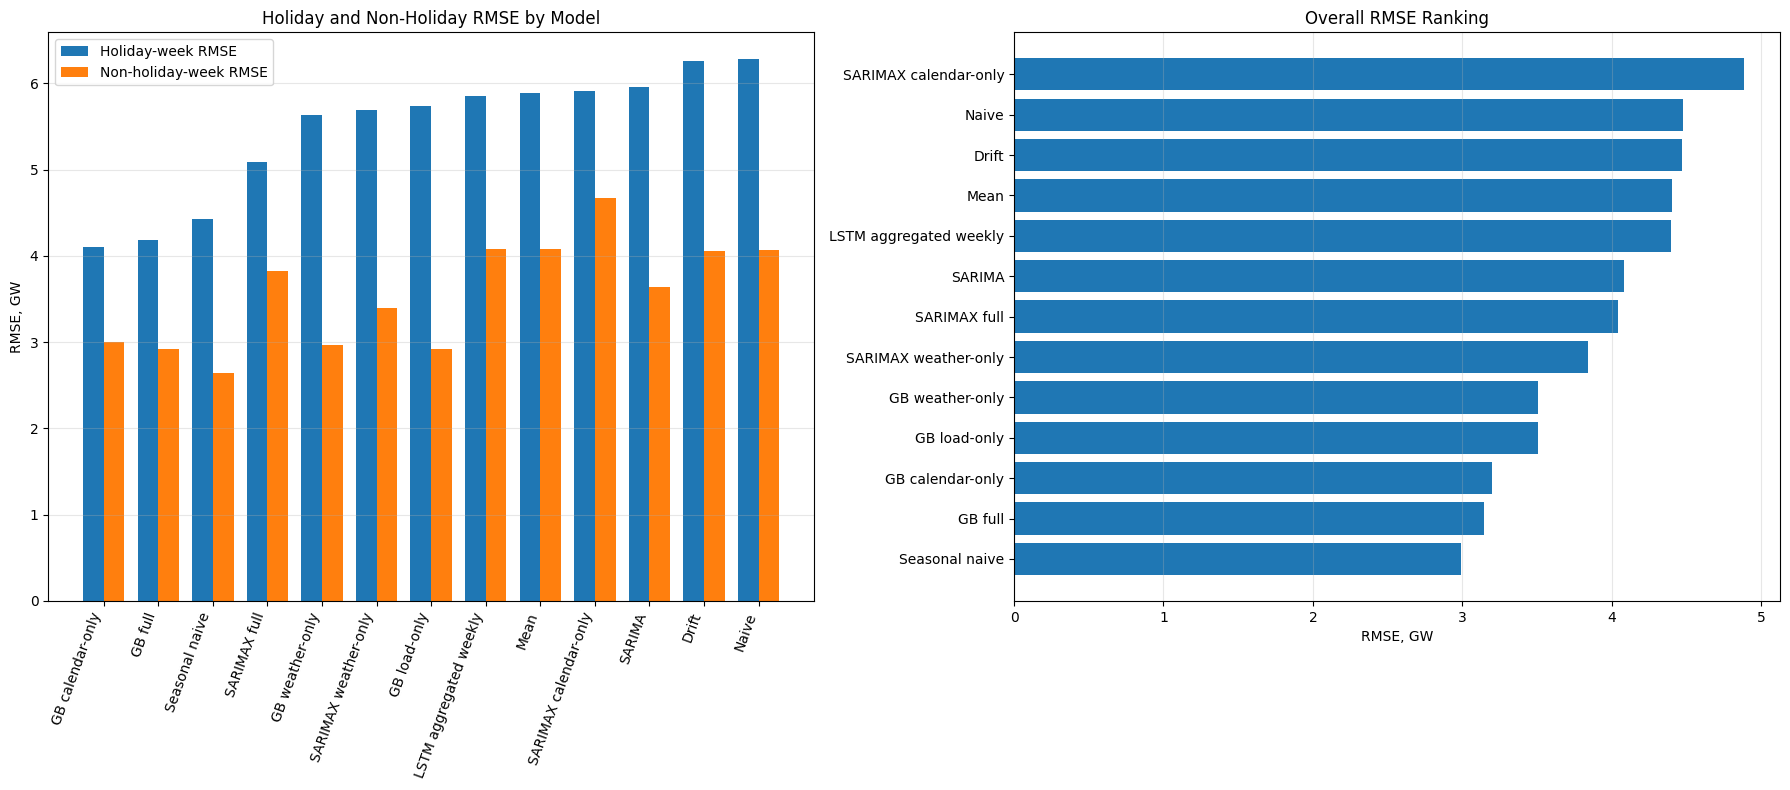

Figures saved in: /content/calendar_outputs/figures
Tables saved in: /content/calendar_outputs/tables


In [ ]:
# =============================================================================
# CELL 10: HOURLY LSTM AND FINAL CALENDAR-SPECIFIC EVALUATION
# =============================================================================

import tensorflow as tf

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)


np.random.seed(
    RANDOM_STATE
)

tf.random.set_seed(
    RANDOM_STATE
)


# Hourly split aligned with the weekly test period
hourly_test_start = (
    y_test.index[0]
    - pd.Timedelta(days=6)
)

hourly_test_end = (
    y_test.index[-1]
    + pd.Timedelta(hours=23)
)

hourly_training_load = (
    hourly_load_gw.loc[
        hourly_load_gw.index
        < hourly_test_start
    ]
    .dropna()
)

hourly_test_load = (
    hourly_load_gw.loc[
        hourly_test_start:
        hourly_test_end
    ]
    .dropna()
)


LSTM_LOOKBACK = 168
LSTM_HORIZON = 24
LSTM_VALIDATION_HOURS = 13 * 168


def create_lstm_sequences(
    values,
    lookback=168,
    horizon=24,
    stride=24
):
    """Create hourly input and output sequences."""

    X = []
    y = []

    for end_position in range(
        lookback,
        len(values) - horizon + 1,
        stride
    ):

        X.append(
            values[
                end_position - lookback:
                end_position
            ]
        )

        y.append(
            values[
                end_position:
                end_position + horizon
            ].reshape(-1)
        )

    return (
        np.asarray(X),
        np.asarray(y)
    )


def build_lstm_model(
    first_units,
    second_units,
    dropout_rate,
    learning_rate
):
    """Create one LSTM architecture."""

    model = Sequential()

    model.add(
        Input(
            shape=(
                LSTM_LOOKBACK,
                1
            )
        )
    )

    if second_units is None:

        model.add(
            LSTM(
                first_units
            )
        )

    else:

        model.add(
            LSTM(
                first_units,
                return_sequences=True
            )
        )

        model.add(
            Dropout(
                dropout_rate
            )
        )

        model.add(
            LSTM(
                second_units
            )
        )

    model.add(
        Dropout(
            dropout_rate
        )
    )

    model.add(
        Dense(
            LSTM_HORIZON
        )
    )

    model.compile(
        optimizer=(
            tf.keras.optimizers.Adam(
                learning_rate=learning_rate
            )
        ),
        loss="mse"
    )

    return model


lstm_candidates = [
    {
        "Architecture": "One layer",
        "First units": 32,
        "Second units": None,
        "Dropout": 0.10,
        "Learning rate": 0.001
    },

    {
        "Architecture": "Two layers",
        "First units": 48,
        "Second units": 24,
        "Dropout": 0.15,
        "Learning rate": 0.001
    }
]


lstm_subtraining = hourly_training_load.iloc[
    :-LSTM_VALIDATION_HOURS
]

lstm_validation = hourly_training_load.iloc[
    -LSTM_VALIDATION_HOURS:
]


validation_scaler = MinMaxScaler()

subtraining_scaled = (
    validation_scaler
    .fit_transform(
        lstm_subtraining
        .to_numpy()
        .reshape(-1, 1)
    )
)

validation_context = pd.concat(
    [
        lstm_subtraining.iloc[
            -LSTM_LOOKBACK:
        ],
        lstm_validation
    ]
)

validation_scaled = (
    validation_scaler
    .transform(
        validation_context
        .to_numpy()
        .reshape(-1, 1)
    )
)


X_lstm_train, y_lstm_train = (
    create_lstm_sequences(
        subtraining_scaled
    )
)

X_lstm_validation, y_lstm_validation = (
    create_lstm_sequences(
        validation_scaled
    )
)


lstm_search_rows = []
best_configuration = None
best_validation_rmse = np.inf


for configuration in lstm_candidates:

    tf.keras.backend.clear_session()

    model = build_lstm_model(
        configuration[
            "First units"
        ],
        configuration[
            "Second units"
        ],
        configuration[
            "Dropout"
        ],
        configuration[
            "Learning rate"
        ]
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    history = model.fit(
        X_lstm_train,
        y_lstm_train,
        validation_data=(
            X_lstm_validation,
            y_lstm_validation
        ),
        epochs=8,
        batch_size=32,
        shuffle=False,
        verbose=0,
        callbacks=[
            early_stopping
        ]
    )

    validation_prediction_scaled = (
        model.predict(
            X_lstm_validation,
            verbose=0
        )
    )

    validation_prediction = (
        validation_scaler
        .inverse_transform(
            validation_prediction_scaled
            .reshape(-1, 1)
        )
        .reshape(
            validation_prediction_scaled.shape
        )
    )

    validation_actual = (
        validation_scaler
        .inverse_transform(
            y_lstm_validation
            .reshape(-1, 1)
        )
        .reshape(
            y_lstm_validation.shape
        )
    )

    architecture_rmse = calculate_rmse(
        validation_actual.ravel(),
        validation_prediction.ravel()
    )

    lstm_search_rows.append(
        {
            "Architecture": configuration[
                "Architecture"
            ],

            "First units": configuration[
                "First units"
            ],

            "Second units": configuration[
                "Second units"
            ],

            "Dropout": configuration[
                "Dropout"
            ],

            "Learning rate": configuration[
                "Learning rate"
            ],

            "Validation RMSE": architecture_rmse,

            "Epochs": len(
                history.history[
                    "loss"
                ]
            )
        }
    )

    if architecture_rmse < best_validation_rmse:

        best_validation_rmse = (
            architecture_rmse
        )

        best_configuration = (
            configuration.copy()
        )


lstm_search_results = pd.DataFrame(
    lstm_search_rows
).sort_values(
    "Validation RMSE"
)

display(
    lstm_search_results.round(4)
)


# Refit selected LSTM
final_scaler = MinMaxScaler()

complete_training_scaled = (
    final_scaler
    .fit_transform(
        hourly_training_load
        .to_numpy()
        .reshape(-1, 1)
    )
)

X_lstm_complete, y_lstm_complete = (
    create_lstm_sequences(
        complete_training_scaled
    )
)

tf.keras.backend.clear_session()

final_lstm = build_lstm_model(
    best_configuration[
        "First units"
    ],
    best_configuration[
        "Second units"
    ],
    best_configuration[
        "Dropout"
    ],
    best_configuration[
        "Learning rate"
    ]
)

final_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

final_history = final_lstm.fit(
    X_lstm_complete,
    y_lstm_complete,
    validation_split=0.10,
    epochs=10,
    batch_size=32,
    shuffle=False,
    verbose=0,
    callbacks=[
        final_early_stopping
    ]
)


# Recursive hourly forecast
history_window = (
    complete_training_scaled[
        -LSTM_LOOKBACK:
    ].copy()
)

required_hours = len(
    hourly_test_load
)

scaled_predictions = []

while len(
    scaled_predictions
) < required_hours:

    next_block = (
        final_lstm(
            history_window[
                np.newaxis,
                :,
                :
            ],
            training=False
        )
        .numpy()
        .reshape(-1)
    )

    remaining_hours = (
        required_hours
        - len(
            scaled_predictions
        )
    )

    scaled_predictions.extend(
        next_block[
            :remaining_hours
        ].tolist()
    )

    history_window = np.vstack(
        [
            history_window[
                len(next_block):
            ],

            next_block.reshape(
                -1,
                1
            )
        ]
    )


hourly_lstm_prediction = (
    final_scaler
    .inverse_transform(
        np.asarray(
            scaled_predictions
        ).reshape(-1, 1)
    )
    .reshape(-1)
)

hourly_lstm_forecast = pd.Series(
    hourly_lstm_prediction,
    index=hourly_test_load.index
)

weekly_lstm_forecast = (
    hourly_lstm_forecast
    .resample("W-SUN")
    .mean()
    .reindex(
        y_test.index
    )
)

forecast_store[
    "LSTM aggregated weekly"
] = weekly_lstm_forecast

results.append(
    evaluate_forecast(
        "LSTM aggregated weekly",
        y_test,
        weekly_lstm_forecast,
        y_train,
        "Operational"
    )
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

axes[0].plot(
    final_history.history[
        "loss"
    ],
    label="Training loss"
)

axes[0].plot(
    final_history.history[
        "val_loss"
    ],
    label="Validation loss"
)

axes[0].set_title(
    "LSTM Learning Curves"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean squared error")
axes[0].legend()
axes[0].grid(alpha=0.3)


display_hours = 8 * 168

axes[1].plot(
    hourly_test_load.index[
        :display_hours
    ],
    hourly_test_load.iloc[
        :display_hours
    ],
    label="Observed"
)

axes[1].plot(
    hourly_lstm_forecast.index[
        :display_hours
    ],
    hourly_lstm_forecast.iloc[
        :display_hours
    ],
    label="LSTM forecast"
)

axes[1].set_title(
    "Hourly LSTM Forecast: First Eight Test Weeks"
)

axes[1].set_xlabel("Date")
axes[1].set_ylabel("Load, GW")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

save_figure(
    "10_lstm_results.png"
)


# Overall model results
final_results = (
    pd.DataFrame(
        results
    )
    .drop_duplicates(
        subset="Model",
        keep="last"
    )
    .sort_values("RMSE")
    .reset_index(drop=True)
)


# Calendar-specific evaluation
def safe_period_metrics(
    y_true,
    y_pred,
    mask
):
    """Calculate MAE and RMSE for one calendar period."""

    valid_mask = (
        mask
        & y_true.notna()
        & y_pred.notna()
    )

    if valid_mask.sum() == 0:

        return {
            "MAE": np.nan,
            "RMSE": np.nan,
            "Bias": np.nan,
            "Observations": 0
        }

    return {
        "MAE": mean_absolute_error(
            y_true[valid_mask],
            y_pred[valid_mask]
        ),

        "RMSE": calculate_rmse(
            y_true[valid_mask],
            y_pred[valid_mask]
        ),

        "Bias": float(
            np.mean(
                y_pred[valid_mask]
                - y_true[valid_mask]
            )
        ),

        "Observations": int(
            valid_mask.sum()
        )
    }


holiday_mask = (
    test_data[
        "is_holiday_week"
    ] == 1
)

ordinary_mask = ~holiday_mask

christmas_mask = (
    test_data[
        "christmas_new_year"
    ] == 1
)

easter_mask = (
    test_data[
        "easter_week"
    ] == 1
)


calendar_evaluation_rows = []

for model_name, prediction in forecast_store.items():

    prediction = prediction.reindex(
        y_test.index
    )

    holiday_metrics = safe_period_metrics(
        y_test,
        prediction,
        holiday_mask
    )

    ordinary_metrics = safe_period_metrics(
        y_test,
        prediction,
        ordinary_mask
    )

    christmas_metrics = safe_period_metrics(
        y_test,
        prediction,
        christmas_mask
    )

    easter_metrics = safe_period_metrics(
        y_test,
        prediction,
        easter_mask
    )

    calendar_evaluation_rows.append(
        {
            "Model": model_name,

            "Holiday MAE": holiday_metrics[
                "MAE"
            ],

            "Holiday RMSE": holiday_metrics[
                "RMSE"
            ],

            "Holiday bias": holiday_metrics[
                "Bias"
            ],

            "Non-holiday MAE": ordinary_metrics[
                "MAE"
            ],

            "Non-holiday RMSE": ordinary_metrics[
                "RMSE"
            ],

            "Christmas RMSE": christmas_metrics[
                "RMSE"
            ],

            "Easter RMSE": easter_metrics[
                "RMSE"
            ]
        }
    )


calendar_evaluation = (
    pd.DataFrame(
        calendar_evaluation_rows
    )
    .sort_values(
        "Holiday RMSE"
    )
    .reset_index(drop=True)
)


display(
    final_results.round(3)
)

display(
    calendar_evaluation.round(3)
)


final_results.to_csv(
    TABLE_DIR
    / "overall_model_results.csv",
    index=False
)

calendar_evaluation.to_csv(
    TABLE_DIR
    / "holiday_specific_results.csv",
    index=False
)


# Final comparison plots
comparison_table = calendar_evaluation.set_index(
    "Model"
)

model_order = (
    comparison_table[
        "Holiday RMSE"
    ]
    .sort_values()
    .index
    .tolist()
)

x_positions = np.arange(
    len(model_order)
)

bar_width = 0.38


figure, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8)
)

axes[0].bar(
    x_positions
    - bar_width / 2,

    comparison_table.loc[
        model_order,
        "Holiday RMSE"
    ],

    width=bar_width,
    label="Holiday-week RMSE"
)

axes[0].bar(
    x_positions
    + bar_width / 2,

    comparison_table.loc[
        model_order,
        "Non-holiday RMSE"
    ],

    width=bar_width,
    label="Non-holiday-week RMSE"
)

axes[0].set_title(
    "Holiday and Non-Holiday RMSE by Model"
)

axes[0].set_ylabel("RMSE, GW")

axes[0].set_xticks(
    x_positions
)

axes[0].set_xticklabels(
    model_order,
    rotation=70,
    ha="right"
)

axes[0].legend()

axes[0].grid(
    axis="y",
    alpha=0.3
)


rmse_ranking = (
    final_results
    .sort_values(
        "RMSE",
        ascending=True
    )
)

axes[1].barh(
    rmse_ranking["Model"],
    rmse_ranking["RMSE"]
)

axes[1].set_title(
    "Overall RMSE Ranking"
)

axes[1].set_xlabel(
    "RMSE, GW"
)

axes[1].grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

save_figure(
    "11_calendar_final_comparison.png"
)


print(
    "Figures saved in:",
    FIGURE_DIR.resolve()
)

print(
    "Tables saved in:",
    TABLE_DIR.resolve()
)